## **Explainable Machine Learning for Predicting Missed Timely Postnatal Care in Kenya**

## 1. Business Understanding

## 1.1 Business Overview

Maternal healthcare is a continuum that includes antenatal care (ANC), delivery care, and postnatal care (PNC). While Kenya has made considerable progress in maternal healthcare utilization, gaps remain in the continuity of care after childbirth.

According to the Kenya Demographic and Health Survey (KDHS) 2022, approximately 98% of women who had a live birth or stillbirth in the two years preceding the survey received ANC from a skilled provider, while about two-thirds attended at least four ANC visits. In addition, 88% of live births occurred in a health facility. However, only 78% of women with a live birth in the two years preceding the survey received a postnatal check within the first two days after birth.

These figures indicate that although contact with the health system is relatively high during pregnancy and delivery, timely postnatal follow-up is not universal. The gap is also uneven across population groups. For example, the KDHS 2022 reports that timely postnatal checks were received by 79% of women in urban areas compared with 69% in rural areas, while coverage ranged from 59% among women in the lowest wealth quintile to 83% among those in the highest wealth quintile.

The availability of detailed maternal-health data from the KDHS 2022 creates an opportunity to use data science to identify characteristics associated with missed timely postnatal care and support more targeted follow-up.

## 1.2  Problem Statement

Despite high utilization of antenatal and facility-based delivery services in Kenya, a proportion of women do not receive a postnatal health check within the first two days after childbirth. Current aggregate statistics describe the size of the gap but do not identify which individual women are more likely to miss timely postnatal care.

Healthcare workers responsible for community-level follow-up may therefore have limited information to prioritize women who could benefit most from additional follow-up.

This project seeks to address this gap by developing an explainable machine-learning model that predicts the likelihood of a woman missing timely postnatal care using demographic, socioeconomic, ANC, delivery, and healthcare-access characteristics from the KDHS 2022 dataset.

The model will not replace healthcare professionals or provide a clinical diagnosis. Instead, it will serve as a decision-support prototype that can help maternal and child health teams identify higher-risk profiles and understand the factors contributing to each prediction.

## 1.3 Business Objective

**Main Objective**

- To develop and deploy an explainable binary classification model that predicts the likelihood of a woman missing timely postnatal care in Kenya and provides understandable explanations for each prediction to support targeted maternal-health follow-up.

**Specific Objectives**


1. *Data Preparation:* To identify, prepare, and engineer relevant demographic, socioeconomic, antenatal care (ANC), delivery, and healthcare-access variables from the KDHS 2022 dataset for predictive modelling.

2. *Predictive Modelling:* To investigate the predictive contribution of demographic, socioeconomic, ANC, delivery, and healthcare-access factors to the likelihood of missing timely postnatal care.

3. *Model Development:* To develop a Logistic Regression model as a baseline and an XGBoost classification model to predict missed timely postnatal care.

4. *Model Evaluation:* To evaluate and compare model performance using PR-AUC as the primary metric, supported by recall, precision, F1-score, ROC-AUC, and confusion-matrix analysis.

5. *Explainable AI:* To apply SHAP-based explainability techniques to identify the key factors contributing to overall model predictions and individual risk predictions.

6. *Decision-Support Prototype:* To develop and deploy an interactive decision-support prototype that generates individual risk predictions and presents the key factors contributing to each prediction.

7. *Geospatial Presentation:* To visualize predicted risk at DHS cluster level using the available GPS data as a presentation layer to support interpretation and potential targeting of maternal-health interventions.

## 1.4 Stakeholders

**Stakeholder	Role / Interest**

- County Ministry of Health MCH Coordinators - Monitor maternal-health outcomes and coordinate targeted interventions

- Community Health Promoters (CHPs) - Conduct community and household follow-up and potentially prioritize women for visits

- Ministry of Health - Use evidence to support maternal-health planning and resource allocation

- Healthcare facilities - Strengthen continuity between ANC, delivery and PNC

- NGOs and development partners - Target maternal-health programmes and resources

- Researchers and public-health analysts - Use evidence to understand factors associated with PNC utilization

- Women and newborns - Ultimate beneficiaries of improved continuity of maternal and newborn care

## 1.5 Metrics of Success

The success of the project will be evaluated at both technical and practical levels.

**Model Performance**

Metrics of Success

1. The analysis should generate actionable insights into the key factors associated with missed timely postnatal care.
2. A machine learning model should identify women at risk of missing timely PNC with a **PR-AUC of at least 0.50**, supported by appropriate recall, precision and F1-score.
3. The final prototype should provide **interpretable, ethically responsible and practically useful** risk predictions for maternal-health follow-up.

**Explainability**

- The model should be able to provide meaningful explanations for individual predictions using SHAP, showing the major factors that increase or decrease predicted risk.

**Practical Success**

The final prototype will be considered successful if a user can:

Enter a woman's profile → receive a predicted probability of missing timely PNC → see the risk classification → understand the main factors contributing to the prediction.

### Why PR-AUC Was Selected as the Primary Metric

PR-AUC (Precision-Recall Area Under the Curve) was selected as the primary evaluation metric because the target variable, `missed_timely_pnc`, is imbalanced. In the final modelling population, approximately **25.7% of women missed timely postnatal care within 48 hours**, while approximately 74.3% received timely care.

The main objective of this project is to identify women who are **at risk of missing timely PNC**, particularly in the presence of class imbalance.

For this project, the approximate no-skill PR-AUC baseline is the positive-class prevalence of **0.256**. A project-specific minimum target of **0.50** was therefore selected as an indication that the model provides useful predictive performance beyond the baseline, while a PR-AUC of **0.60 or higher** would indicate stronger performance.

## 2. Data Understanding


### 2.1 Data Source 

The raw KDHS 2022 dataset contains **13,184 records** across **919 variables**.

### 2.2 Eligible Population

This recode is pregnancy-indexed, not birth-indexed. Eligibility is defined using `m80`
("pregnancy outcome for this section"), filtered to `m80 ∈ {1, 3}` — each woman's most
recent **live birth** or **stillbirth**. Stillbirths are retained by design, since mothers
who experience a stillbirth still require postpartum care.

| Stage | Records |
|---|---|
| Total records (raw dataset) | 13,184 |
| Eligible (most recent live birth/stillbirth) | 10,606 |
| After excluding unknown-target timing | 10,570 |
| After deduplication (one record per woman) | **10,505** (final) |

The final modelling population consists of **10,505 women**, each contributing exactly one
observation, with a validated class balance of 74.4% timely vs. 25.6% missed timely postnatal care.

### 2.3 Relevant Variables for PNC Prediction

13 predictor variables were selected from the KDHS 2022 dataset:

| Variable Code | Description |
|---|---|
| `v012` | Maternal age |
| `v106` | Education level |
| `v501` | Marital status |
| `v714` | Employment status |
| `v190` | Household wealth |
| `v201` | Children ever born |
| `m10` | Pregnancy intention |
| `m14` | Number of ANC visits |
| `m13` | Timing of first ANC visit |
| `m15` | Place of delivery |
| `m17` | Caesarean delivery |
| `v025` | Urban/rural residence |
| `v024` | Region |

In [1]:
# Portable setup: read the repository ZIP files directly (no extraction required)
from pathlib import Path
import io
import zipfile

import numpy as np
import pandas as pd
from IPython.display import display

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (folder for folder in [cwd, *cwd.parents] if (folder / "data" / "raw" / "KENR8CDT.zip").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate data/raw/KENR8CDT.zip. Run this notebook from inside the cloned repository."
    )

RAW_DIR = PROJECT_ROOT / "data" / "raw"
MATERNAL_ZIP = RAW_DIR / "KENR8CDT.zip"
GPS_ZIP = RAW_DIR / "KEGE8AFL.zip"

for archive_path in (MATERNAL_ZIP, GPS_ZIP):
    if not archive_path.exists():
        raise FileNotFoundError(f"Missing required archive: {archive_path.relative_to(PROJECT_ROOT)}")

print(f"Maternal source: {MATERNAL_ZIP.relative_to(PROJECT_ROOT)}")
print(f"GPS source:      {GPS_ZIP.relative_to(PROJECT_ROOT)}")

Maternal source: data\raw\KENR8CDT.zip
GPS source:      data\raw\KEGE8AFL.zip


In [2]:
# Load the pregnancy and postnatal-care recode directly from its ZIP archive.
with zipfile.ZipFile(MATERNAL_ZIP) as archive:
    stata_name = next(name for name in archive.namelist() if name.upper().endswith(".DTA"))
    stata_bytes = io.BytesIO(archive.read(stata_name))

reader = pd.io.stata.StataReader(stata_bytes)
df = reader.read(convert_categoricals=False)
variable_labels = reader.variable_labels()
value_labels = reader.value_labels()

print(f"Loaded: {df.shape[0]:,} records x {df.shape[1]} variables")

Loaded: 13,184 records x 919 variables


In [3]:
# Verify the GPS archive without loading coordinates as model inputs.
with zipfile.ZipFile(GPS_ZIP) as archive:
    gps_shapefile = next(name for name in archive.namelist() if name.upper().endswith(".SHP"))

print(f"Verified GPS file inside ZIP: {gps_shapefile}")
print("GPS coordinates are reserved for mapping and are not model predictors.")

Verified GPS file inside ZIP: KEGE8AFL.shp
GPS coordinates are reserved for mapping and are not model predictors.


## 2.4 Candidate Predictors

Predictors were mapped from the project proposal to their DHS variable codes, giving the
13 candidate variables used for postnatal-care risk stratification.

In [4]:
predictor_vars = {
    "v012": "Maternal age", "v106": "Education level", "v501": "Marital status",
    "v714": "Employment status", "v190": "Household wealth", "v201": "Children ever born",
    "m10": "Pregnancy intention", "m14": "Number of ANC visits", "m13": "Timing of first ANC visit",
    "m15": "Place of delivery", "m17": "Caesarean delivery", "v025": "Urban/rural residence",
    "v024": "Region"
}

summary = []
for var, label in predictor_vars.items():
    summary.append({
        "Variable": var, "Description": label
    })

pd.DataFrame(summary)

,Variable,Description
0,v012,Maternal age
1,v106,Education level
2,v501,Marital status
3,v714,Employment status
4,v190,Household wealth
5,v201,Children ever born
6,m10,Pregnancy intention
7,m14,Number of ANC visits
8,m13,Timing of first ANC visit
9,m15,Place of delivery


## 3. Data Preparation 

This section converts the validated population from Data Understanding into the final modelling table. It keeps exactly **13 approved predictors and one binary target**. Identifiers, survey-design fields, auditing fields, duplicate geographic representations, and target-source variables are excluded from the exported model inputs.

### 3.1 Eligible Population

This recode is **pregnancy-indexed**, not birth-indexed. The eligibility variable is `m80`
("pregnancy outcome for this section"), which flags each woman's most recent pregnancy outcome:

| Code | Meaning |
|---|---|
| 1 | Most recent live birth |
| 3 | Most recent stillbirth |

Filtering to `m80 ∈ {1, 3}` restricts the data to each woman's most recent live birth or stillbirth —
the population this project defines as eligible for postnatal-care risk stratification. Stillbirths
are retained by design: mothers who experience a stillbirth still require postpartum care.

In [5]:
# Full breakdown of ALL pregnancy outcomes in the raw data, before any filtering.
# This shows exactly what gets excluded and why: prior pregnancies and miscarriages/abortions
# are out of scope, since DHS only collects postnatal-care data for a woman's most recent
# pregnancy outcome.
m80_labels = {
    1: "Most recent live birth",
    2: "Prior live birth",
    3: "Most recent stillbirth",
    4: "Prior stillbirth",
    5: "Miscarriage/abortion"
}

outcome_counts = df["m80"].value_counts().sort_index()
outcome_summary = pd.DataFrame({
    "Code": outcome_counts.index,
    "Meaning": [m80_labels.get(c, "Unknown") for c in outcome_counts.index],
    "Count": outcome_counts.values
})
outcome_summary["% of total"] = (outcome_summary["Count"] / len(df) * 100).round(1)

print(f"Total records before filtering: {len(df):,}\n")
print(outcome_summary.to_string(index=False))

Total records before filtering: 13,184

 Code                Meaning  Count  % of total
    1 Most recent live birth  10412        79.0
    2       Prior live birth   1317        10.0
    3 Most recent stillbirth    194         1.5
    4       Prior stillbirth     13         0.1
    5   Miscarriage/abortion   1248         9.5


Applying the `m80 ∈ {1, 3}` filter gives the eligible population, along with a check for any women who appear more than once (multiple "most recent" outcomes recorded across different interview sections).

In [6]:
# Restrict to each woman's most recent live birth (m80=1) or stillbirth (m80=3).
# Stillbirths are retained by design (see markdown above) - mothers still need postpartum care.
eligible = df[df["m80"].isin([1, 3])].copy()

# Breakdown of the eligible population after filtering
print(f"Eligible records (most recent live birth or stillbirth): {eligible.shape[0]:,}")
print(f"Unique women: {eligible['caseid'].nunique():,}")
print(f"Unique survey clusters: {eligible['v001'].nunique():,}")
print()

# Confirm the split between live births and stillbirths within the eligible set
eligible_breakdown = eligible["m80"].value_counts().sort_index()
eligible_summary = pd.DataFrame({
    "Code": eligible_breakdown.index,
    "Meaning": [m80_labels.get(c, "Unknown") for c in eligible_breakdown.index],
    "Count": eligible_breakdown.values
})
eligible_summary["% of eligible"] = (eligible_summary["Count"] / len(eligible) * 100).round(1)

print(eligible_summary.to_string(index=False))
print()

# Note: a woman can appear more than once here if DHS recorded two separate "most recent"
# outcomes for her (e.g. a recent live birth AND a separate recent pregnancy-loss entry).
# We flag this now and resolve it after the target is built (see below), since we need the
# target value to decide which of a woman's records to keep if we ever need to pick one.
duplicate_women = eligible["caseid"].value_counts()
duplicate_women = duplicate_women[duplicate_women > 1]
print(f"Women appearing more than once in the eligible set: {len(duplicate_women)}")

Eligible records (most recent live birth or stillbirth): 10,606
Unique women: 10,540
Unique survey clusters: 1,680

 Code                Meaning  Count  % of eligible
    1 Most recent live birth  10412           98.2
    3 Most recent stillbirth    194            1.8

Women appearing more than once in the eligible set: 66


### 3.2  Target Variable: Missed Timely Postnatal Care

The mother's postnatal check is captured across two DHS routing paths:
- **Pre-discharge check** (facility path): `m62` (checked, yes/no) → `m63` (timing)
- **Post-discharge / home-delivery check** (catch-all path): `m66` (checked, yes/no) → `m67` (timing)

Timing codes follow the DHS convention: `1XX` = hours, `2XX` = days, `3XX` = weeks, `998` = don't know.

**Target rule** (any provider — matches the standard global PNC-timeliness indicator, which does not
restrict by provider type):
- **0 (timely):** a check occurred within 48 hours on either path (hours `100`–`148`, or days `201`–`202`)
- **1 (missed):** no check occurred on either path, or the earliest check occurred at 3+ days / weeks
- **Excluded:** timing coded `998` (don't know) — only 40 records (0.38%), too small to justify an
  imputation assumption

In [7]:
# Classify each routing path (pre-discharge and post-discharge/home) as timely, late,
# no check occurred, or not applicable - then combine into the final binary target.
def classify_check(check_flag, timing_code):
    if check_flag == 1:
        if pd.isna(timing_code) or timing_code == 998:
            return "unknown"
        elif 100 <= timing_code <= 148 or 201 <= timing_code <= 202:
            return "timely"
        elif timing_code >= 203:
            return "late"
        return "unknown"
    elif check_flag == 0:
        return "no_check"
    return "not_applicable"

def combine_target(pre, post):
    if pre == "timely" or post == "timely":
        return 0
    if pre == "unknown" or post == "unknown":
        return np.nan
    return 1

eligible["pre_discharge_status"] = eligible.apply(lambda r: classify_check(r["m62"], r["m63"]), axis=1)
eligible["post_discharge_status"] = eligible.apply(lambda r: classify_check(r["m66"], r["m67"]), axis=1)
eligible["missed_timely_pnc"] = eligible.apply(
    lambda r: combine_target(r["pre_discharge_status"], r["post_discharge_status"]), axis=1
)

# Exclude the small number of records where timing could not be determined (998/DK)
model_df = eligible[eligible["missed_timely_pnc"].notna()].copy()
model_df["missed_timely_pnc"] = model_df["missed_timely_pnc"].astype(int)

print(f"Final modelling population (before dedup): {model_df.shape[0]:,} records")
print(model_df["missed_timely_pnc"].value_counts(normalize=True).mul(100).round(1))

Final modelling population (before dedup): 10,570 records
missed_timely_pnc
0    74.3
1    25.7
Name: proportion, dtype: float64


### 3.2.1 Reconciling the Record Count and Checking for Duplicate Women

Two things to confirm before this becomes the final modelling dataset:
1. Exactly how many records were excluded when building the target, and why.
2. Whether any woman appears more than once (66 were flagged earlier, in the full eligible
   set) - and if so, keep only her most recent pregnancy record, so each woman contributes
   exactly one observation to the model.

In [8]:
# Confirm exactly why the record count drops from 10,606 (eligible) to a smaller number here:
# every record where m63/m67 timing was coded 998 (Don't know) was excluded from the target,
# since we can't safely assign timely/missed without guessing.
n_eligible = eligible.shape[0]
n_unknown = eligible["missed_timely_pnc"].isna().sum()
n_model = model_df.shape[0]

print(f"Eligible population:           {n_eligible:,}")
print(f"Excluded - unknown target (m63/m67 = 998, Don't know): {n_unknown}")
print(f"Modelling population (before dedup): {n_model:,}")
assert n_eligible - n_unknown == n_model, "Numbers don't reconcile - check filtering logic"
print(f"\nConfirmed: {n_eligible:,} - {n_unknown} unknown-target rows = {n_model:,}")

Eligible population:           10,606
Excluded - unknown target (m63/m67 = 998, Don't know): 36
Modelling population (before dedup): 10,570

Confirmed: 10,606 - 36 unknown-target rows = 10,570


In [9]:
# Check for women appearing more than once in the modelling population
dup_counts = model_df["caseid"].value_counts()
dup_women = dup_counts[dup_counts > 1]

print(f"Women appearing more than once: {len(dup_women)}")
print(f"Total records involved: {dup_women.sum()}")

if len(dup_women) > 0:
    # p18 = century day code (cdc) of pregnancy outcome - a precise, sortable chronological
    # value used to determine which of a woman's records is truly the most recent.
    sample = model_df[model_df["caseid"].isin(dup_women.index)][
        ["caseid", "m80", "p1", "p2", "p18", "missed_timely_pnc"]
    ].sort_values(["caseid", "p18"])
    print("\nSample of duplicate records (chronological order via p18):")
    print(sample.head(20))
    print(f"\np18 missing for {sample['p18'].isna().sum()} of these rows")

Women appearing more than once: 65
Total records involved: 130

Sample of duplicate records (chronological order via p18):
               caseid  m80  p1    p2    p18  missed_timely_pnc
37           8  71  2    3   1  2021  44206                  0
36           8  71  2    1  12  2021  44548                  0
119         18  67  2    3   4  2021  44290                  1
118         18  67  2    1   2  2022  44598                  1
305         43  46 15    3   7  2019  43674                  0
304         43  46 15    1  10  2020  44115                  0
712         98   8  6    3   1  2020  43847                  0
711         98   8  6    1   2  2021  44248                  1
861        116  12  2    3   8  2020  44047                  1
860        116  12  2    1   8  2021  44413                  0
1107       136  12  2    3   2  2020  43870                  1
1106       136  12  2    1  11  2021  44503                  1
1155       139  56  2    3   3  2020  43906               

Note: this shows **65** duplicate women here, one fewer than the **66** found earlier in the
full eligible set. That's expected: one of the original 66 had one of her two records excluded
just above (unknown target timing), leaving her with only one record in `model_df` - so she no
longer appears as a "duplicate" at this point, even though she started as one. This is confirmed
explicitly further down.

### 3.2.2 Deduplicating to One Record per Woman

Each woman should contribute exactly one observation to the model - both to avoid distorting
the class balance and to prevent the same woman's data leaking across train/test splits later.
For any woman with more than one eligible record, we keep only the most recent pregnancy,
using `p18` (century day code of pregnancy outcome) as the chronological key, with `p2`/`p1`
(year/month of outcome) as a fallback if `p18` is missing for a given row. `p18` is fully
populated for these rows, so no fallback is actually needed here.

In [10]:
import numpy as np

def pregnancy_date_key(row):
    if pd.notna(row.get("p18")):
        return row["p18"]
    if pd.notna(row.get("p2")) and pd.notna(row.get("p1")):
        return row["p2"] * 12 + row["p1"]  # fallback: year*12 + month
    return np.nan

model_df["_date_key"] = model_df.apply(pregnancy_date_key, axis=1)

before_n = model_df.shape[0]
before_women = model_df["caseid"].nunique()

# Keep only the most recent record per woman
model_df = (
    model_df.sort_values("_date_key", ascending=False)
    .drop_duplicates(subset="caseid", keep="first")
    .drop(columns="_date_key")
)

print(f"Before dedup: {before_n:,} records, {before_women:,} unique women")
print(f"After dedup:  {model_df.shape[0]:,} records, {model_df['caseid'].nunique():,} unique women")
print(f"Records dropped: {before_n - model_df.shape[0]}")
print()
print("Final target distribution after dedup:")
print(model_df["missed_timely_pnc"].value_counts(normalize=True).mul(100).round(1))

Before dedup: 10,570 records, 10,505 unique women
After dedup:  10,505 records, 10,505 unique women
Records dropped: 65

Final target distribution after dedup:
missed_timely_pnc
0    74.4
1    25.6
Name: proportion, dtype: float64


### 3.2.3 Confirming the Final Unique-Women Count

After deduplication, `model_df` has one record per woman. We'd expect this to match the
10,540 unique women found in the eligible population - let's check.

In [11]:
# %% Confirm final unique-women count against the eligible population's 10,540
print(f"Final unique women in model_df: {model_df['caseid'].nunique():,}")
print(f"Expected (from eligible population): 10,540")
print(f"Difference: {10540 - model_df['caseid'].nunique()} (women who lost both records to unknown-target exclusion)")

Final unique women in model_df: 10,505
Expected (from eligible population): 10,540
Difference: 35 (women who lost both records to unknown-target exclusion)


### 3.2.4 Explaining the Gap

The final count is short by 35 women. To confirm why, we check whether the excluded
unknown-target records (36 total) belong to women who had a second, valid record to fall back
on (originally-duplicate women), or to women whose *only* eligible record was excluded outright.

In [12]:
# Identify which unknown-target record belongs to a duplicate woman vs. a single-record woman
# IMPORTANT: use duplicates from the full eligible set (before target exclusion), not model_df,
# since a woman who lost one of her two records to unknown-target exclusion would no longer
# appear as "duplicate" in model_df even though she originally had 2 eligible records.
eligible_dup_counts = eligible["caseid"].value_counts()
eligible_dup_caseids = set(eligible_dup_counts[eligible_dup_counts > 1].index)

unknown_records = eligible[eligible["missed_timely_pnc"].isna()]
unknown_from_dup_women = unknown_records[unknown_records["caseid"].isin(eligible_dup_caseids)]
unknown_from_single_women = unknown_records[~unknown_records["caseid"].isin(eligible_dup_caseids)]

print(f"Unknown-target records from (originally) duplicate women: {len(unknown_from_dup_women)}")
print(f"Unknown-target records from single-record women: {len(unknown_from_single_women)}")

Unknown-target records from (originally) duplicate women: 1
Unknown-target records from single-record women: 35


### 3.2.5 Data Filtering, Eligibility and Final Sample Selection

Putting the full chain together:

`13,184` total records → `10,606` eligible (most recent live birth/stillbirth) → `10,570`
after excluding 36 unknown-target records → **`10,505`** after deduplication (65 duplicate
records removed, one row kept per woman).

**Final validated class balance:** 74.4% timely / 25.6% missed timely PNC, across 10,505 women
- each woman contributing exactly one observation.

### 3.3 Candidate Predictors and Missingness

Predictors were mapped from the project proposal to their DHS variable codes, then checked for
missingness across the full eligible population (10,606 records) - independent of target
construction or deduplication, since predictor availability is a property of the raw data itself.

In [13]:
predictor_vars = {
    "v012": "Maternal age", "v106": "Education level", "v501": "Marital status",
    "v714": "Employment status", "v190": "Household wealth", "v201": "Children ever born",
    "m10": "Pregnancy intention", "m14": "Number of ANC visits", "m13": "Timing of first ANC visit",
    "m15": "Place of delivery", "m17": "Caesarean delivery", "v025": "Urban/rural residence",
    "v024": "Region"
}

summary = []
for var, label in predictor_vars.items():
    n_missing = eligible[var].isna().sum()
    summary.append({
        "Variable": var, "Description": label,
        "Missing": n_missing, "Missing %": round(100 * n_missing / len(eligible), 1)
    })

pd.DataFrame(summary)

,Variable,Description,Missing,Missing %
0,v012,Maternal age,0,0.0
1,v106,Education level,0,0.0
2,v501,Marital status,0,0.0
3,v714,Employment status,0,0.0
4,v190,Household wealth,0,0.0
5,v201,Children ever born,0,0.0
6,m10,Pregnancy intention,0,0.0
7,m14,Number of ANC visits,0,0.0
8,m13,Timing of first ANC visit,399,3.8
9,m15,Place of delivery,0,0.0


### 3.4 Validated one-woman table

The preceding section has already applied the eligibility rule, constructed the target, excluded uncertain outcomes, and retained one usable record per woman. We copy that table so cleaning operations do not alter the earlier audit trail.

In [14]:
from pathlib import Path

clean = model_df.copy()

# Locate the repository root so the export works from the root or notebooks folder.
cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (folder for folder in [cwd, *cwd.parents] if (folder / "data" / "raw" / "KENR8CDT.zip").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate data/raw/KENR8CDT.zip. Run this notebook from inside the cloned repository."
    )

print(f"Validated rows entering preparation: {len(clean):,}")
print(f"Unique women: {clean['caseid'].nunique():,}")

Validated rows entering preparation: 10,505
Unique women: 10,505


### 3.4.1 Create Understandable Fields

DHS uses numeric codes to store categories. The next cell:

- changes `98 = Don't know` to a true missing value for ANC timing and visits;
- groups detailed delivery places into useful categories;
- adds readable labels for the main categorical predictors.

Missing predictor values are **kept** for now. Imputation should be learned from training data only, after the train/test split, to avoid data leakage.

In [15]:
# Replace DHS special codes with true missing values.
clean["m13"] = clean["m13"].replace({98: np.nan, 99: np.nan})
clean["m14"] = clean["m14"].replace({98: np.nan, 99: np.nan})

education = {0: "No education", 1: "Primary", 2: "Secondary", 3: "Higher"}
marital = {
    0: "Never married", 1: "Married", 2: "Living with partner",
    3: "Widowed", 4: "Divorced", 5: "Separated",
}
wealth = {1: "Poorest", 2: "Poorer", 3: "Middle", 4: "Richer", 5: "Richest"}
yes_no = {0: "No", 1: "Yes"}
residence = {1: "Urban", 2: "Rural"}
intention = {1: "Wanted then", 2: "Wanted later", 3: "Wanted no more"}
county = {
    1: "Mombasa", 2: "Kwale", 3: "Kilifi", 4: "Tana River", 5: "Lamu",
    6: "Taita Taveta", 7: "Garissa", 8: "Wajir", 9: "Mandera", 10: "Marsabit",
    11: "Isiolo", 12: "Meru", 13: "Tharaka-Nithi", 14: "Embu", 15: "Kitui",
    16: "Machakos", 17: "Makueni", 18: "Nyandarua", 19: "Nyeri", 20: "Kirinyaga",
    21: "Murang'a", 22: "Kiambu", 23: "Turkana", 24: "West Pokot", 25: "Samburu",
    26: "Trans Nzoia", 27: "Uasin Gishu", 28: "Elgeyo-Marakwet", 29: "Nandi",
    30: "Baringo", 31: "Laikipia", 32: "Nakuru", 33: "Narok", 34: "Kajiado",
    35: "Kericho", 36: "Bomet", 37: "Kakamega", 38: "Vihiga", 39: "Bungoma",
    40: "Busia", 41: "Siaya", 42: "Kisumu", 43: "Homa Bay", 44: "Migori",
    45: "Kisii", 46: "Nyamira", 47: "Nairobi",
}


def delivery_place_group(code):
    if pd.isna(code):
        return pd.NA
    code = int(code)
    if 10 <= code <= 19:
        return "Home"
    if 20 <= code <= 29:
        return "Public facility"
    if 30 <= code <= 39:
        return "Private facility"
    if 40 <= code <= 49:
        return "Faith-based/NGO facility"
    if code == 96:
        return "Other"
    return pd.NA


model_data = pd.DataFrame({
    "maternal_age": clean["v012"].astype("Int64"),
    "county_name": clean["v024"].map(county),
    "residence": clean["v025"].map(residence),
    "education_level": clean["v106"].map(education),
    "wealth_quintile": clean["v190"].map(wealth),
    "children_ever_born": clean["v201"].astype("Int64"),
    "marital_status": clean["v501"].map(marital),
    "currently_working": clean["v714"].map(yes_no),
    "pregnancy_intention": clean["m10"].map(intention),
    "first_anc_month": clean["m13"].astype("Int64"),
    "anc_visits": clean["m14"].astype("Int64"),
    "delivery_place": clean["m15"].map(delivery_place_group),
    "caesarean_delivery": clean["m17"].map(yes_no),
    "missed_timely_pnc": clean["missed_timely_pnc"].astype("int8"),
})

display(model_data.head())

,maternal_age,county_name,residence,education_level,wealth_quintile,children_ever_born,marital_status,currently_working,pregnancy_intention,first_anc_month,anc_visits,delivery_place,caesarean_delivery,missed_timely_pnc
4239,38,Embu,Rural,Higher,Richer,3,Married,Yes,Wanted then,3,6,Private facility,Yes,0
11894,23,Homa Bay,Urban,Secondary,Richest,1,Married,Yes,Wanted then,6,3,Private facility,Yes,0
8271,35,Baringo,Rural,Secondary,Poorest,6,Married,No,Wanted then,3,6,Public facility,No,0
5531,24,Murang'a,Rural,Higher,Middle,3,Living with partner,No,Wanted later,6,4,Public facility,No,1
3721,24,Meru,Rural,Secondary,Poorest,2,Living with partner,No,Wanted then,5,4,Public facility,No,1


### 3.4.2 Create a separate visualization table

The modelling table stays limited to 13 predictors and one target. For charts, maps, and survey-representative summaries, we create a separate table that restores only four useful context fields:

- `cluster_id` for later joins to the displaced DHS mapping file;
- `sample_weight` for representative percentages and rates;
- `county_code` for ordered geographic joins;
- `pregnancy_outcome` for comparing live births and stillbirths.

Woman, household, and respondent identifiers are deliberately excluded because they are unnecessary for visualizations.

In [16]:
visualization_context = pd.DataFrame({
    "cluster_id": clean["v001"].astype("Int64"),
    "sample_weight": clean["v005"] / 1_000_000,
    "county_code": clean["v024"].astype("Int64"),
    "pregnancy_outcome": clean["m80"].map({1: "Live birth", 3: "Stillbirth"}),
})

visualization_data = pd.concat([visualization_context, model_data], axis=1)

assert visualization_data.shape == (len(model_data), 18)
assert visualization_data["sample_weight"].gt(0).all()
assert visualization_data["cluster_id"].notna().all()
assert visualization_data["county_code"].between(1, 47).all()

print(f"Model table:         {model_data.shape[0]:,} rows x {model_data.shape[1]} columns")
print(f"Visualization table: {visualization_data.shape[0]:,} rows x {visualization_data.shape[1]} columns")
display(visualization_data.head())

Model table:         10,505 rows x 14 columns
Visualization table: 10,505 rows x 18 columns


,cluster_id,sample_weight,county_code,pregnancy_outcome,maternal_age,county_name,residence,education_level,wealth_quintile,children_ever_born,marital_status,currently_working,pregnancy_intention,first_anc_month,anc_visits,delivery_place,caesarean_delivery,missed_timely_pnc
4239,480,0.827770,14,Live birth,38,Embu,Rural,Higher,Richer,3,Married,Yes,Wanted then,3,6,Private facility,Yes,0
11894,1495,0.832490,43,Live birth,23,Homa Bay,Urban,Secondary,Richest,1,Married,Yes,Wanted then,6,3,Private facility,Yes,0
8271,1033,0.471916,30,Live birth,35,Baringo,Rural,Secondary,Poorest,6,Married,No,Wanted then,3,6,Public facility,No,0
5531,722,1.528534,21,Live birth,24,Murang'a,Rural,Higher,Middle,3,Living with partner,No,Wanted later,6,4,Public facility,No,1
3721,382,1.572604,12,Live birth,24,Meru,Rural,Secondary,Poorest,2,Living with partner,No,Wanted then,5,4,Public facility,No,1


### 3.4.3 Validate the cleaned table

These checks act like guardrails. If a future file behaves differently, the notebook stops instead of silently producing a questionable dataset.

In [17]:
assert len(model_data) == clean["caseid"].nunique(), "The final table is not one row per woman."
assert model_data.shape[1] == 14, "Expected 13 predictors and one target."
assert model_data["missed_timely_pnc"].isin([0, 1]).all(), "Target contains values other than 0/1."
assert model_data["maternal_age"].between(15, 49).all(), "Maternal age is outside 15–49."
assert model_data["county_name"].notna().all(), "A county code could not be translated."
assert model_data["first_anc_month"].dropna().between(1, 10).all(), "ANC month is implausible."
assert model_data["anc_visits"].dropna().between(0, 20).all(), "ANC visit count is implausible."

target_source_fields = {"m62", "m63", "m66", "m67", "pre_discharge_status", "post_discharge_status"}
assert target_source_fields.isdisjoint(model_data.columns), "Target-source fields leaked into the model table."

non_model_fields = {
    "woman_id", "cluster_id", "household_id", "respondent_line", "sample_weight",
    "county_code", "pregnancy_outcome",
}
assert non_model_fields.isdisjoint(model_data.columns), "A non-model field remains in the export."

validation = pd.DataFrame({
    "check": [
        "Rows in final table", "Unique women", "Columns in final table", "Predictor columns",
        "Missing target values", "Target values", "Target leakage fields", "Non-model fields",
    ],
    "result": [
        f"{len(model_data):,}", f"{clean['caseid'].nunique():,}", model_data.shape[1], model_data.shape[1] - 1,
        model_data["missed_timely_pnc"].isna().sum(),
        sorted(model_data["missed_timely_pnc"].unique().tolist()),
        sorted(target_source_fields.intersection(model_data.columns)),
        sorted(non_model_fields.intersection(model_data.columns)),
    ],
})
display(validation)
print("All validation checks passed.")

,check,result
0,Rows in final table,"10,505"
1,Unique women,"10,505"
2,Columns in final table,14
3,Predictor columns,13
4,Missing target values,0
5,Target values,"[0, 1]"
6,Target leakage fields,[]
7,Non-model fields,[]


All validation checks passed.


### 3.5 Review Missing Information

This table shows which fields still have blanks after special-code cleaning. Blanks are not automatically errors: for example, ANC timing can be missing when no ANC visit occurred.


In [18]:
missing_summary = pd.DataFrame({
    "missing_rows": model_data.isna().sum(),
    "missing_percent": (100 * model_data.isna().mean()).round(2),
}).sort_values(["missing_rows", "missing_percent"], ascending=False)

display(missing_summary.loc[missing_summary["missing_rows"] > 0])

,missing_rows,missing_percent
first_anc_month,397,3.78
anc_visits,10,0.10


### 3.5.1 Handling missing values

The missing values are filled during modeling, numerical and categorical imputation fitted using the training data only ans subsequently applied to test data.
This was done so as to prevent data leakage.

### 3.6 Save the model-ready dataset

The final CSV contains only the **13 approved model predictors** and the binary target. Identifiers, survey-design fields, duplicate geographic representations, pregnancy-outcome auditing fields, and raw postnatal routing fields are excluded.

In [19]:
OUTPUT_RELATIVE_PATH = Path("data") / "processed" / "maternal_pnc_model_inputs.csv"
OUTPUT_FILE = PROJECT_ROOT / OUTPUT_RELATIVE_PATH
OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)

try:
    model_data.to_csv(OUTPUT_FILE, index=False)
except PermissionError:
    from datetime import datetime

    fallback_name = f"maternal_pnc_model_inputs_{datetime.now():%Y%m%d_%H%M%S}.csv"
    OUTPUT_RELATIVE_PATH = Path("data") / "processed" / fallback_name
    OUTPUT_FILE = PROJECT_ROOT / OUTPUT_RELATIVE_PATH
    model_data.to_csv(OUTPUT_FILE, index=False)
    print("The standard output file is open in another program, so a timestamped copy was saved instead.")

print(f"Saved {len(model_data):,} rows and {model_data.shape[1]} columns to:")
print(OUTPUT_RELATIVE_PATH.as_posix())

Saved 10,505 rows and 14 columns to:
data/processed/maternal_pnc_model_inputs.csv


### 3.7 Save the visualization dataset

This separate export supports weighted charts and geographic summaries without accidentally expanding the feature matrix used by the model.

In [20]:
VISUALIZATION_RELATIVE_PATH = Path("data") / "processed" / "maternal_pnc_visualization_data.csv"
VISUALIZATION_FILE = PROJECT_ROOT / VISUALIZATION_RELATIVE_PATH

try:
    visualization_data.to_csv(VISUALIZATION_FILE, index=False)
except PermissionError:
    from datetime import datetime

    fallback_name = f"maternal_pnc_visualization_data_{datetime.now():%Y%m%d_%H%M%S}.csv"
    VISUALIZATION_RELATIVE_PATH = Path("data") / "processed" / fallback_name
    VISUALIZATION_FILE = PROJECT_ROOT / VISUALIZATION_RELATIVE_PATH
    visualization_data.to_csv(VISUALIZATION_FILE, index=False)
    print("The standard visualization file is open, so a timestamped copy was saved instead.")

print(f"Saved {len(visualization_data):,} rows and {visualization_data.shape[1]} columns to:")
print(VISUALIZATION_RELATIVE_PATH.as_posix())

Saved 10,505 rows and 18 columns to:
data/processed/maternal_pnc_visualization_data.csv


The cleaned dataset is saved as a separate CSV file for use in **visualizations and geographic analysis**.

Keeping this dataset separate from the model feature matrix helps maintain a clear distinction between data used for **predictive modelling** and data used for **reporting, visualization, and mapping**.

The exported file contains the cleaned observations required for the subsequent EDA and geospatial analysis.

## 4. Exploratory Data Analysis

Exploratory data analysis (EDA) is used here as the final bridge between data preparation and modelling. It examines the cleaned visualization table created in Section 3, without reloading a CSV or changing the raw DHS dataframe.

#### Target question

Which characteristics are associated with women missing timely postnatal care (PNC) within two days after childbirth?


#### Target variable

- `0` = received timely PNC
- `1` = missed timely PNC

> 

In [21]:
# Prepare the cleaned visualization table for EDA.
# Keep a separate name so the raw DHS dataframe `df` remains unchanged.
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", palette="deep")

eda_df = visualization_data.copy()
TARGET = "missed_timely_pnc"
target_labels = {0: "Received timely PNC", 1: "Missed timely PNC"}

print(f"EDA dataset: {eda_df.shape[0]:,} rows and {eda_df.shape[1]} columns")
display(eda_df.head())

EDA dataset: 10,505 rows and 18 columns


,cluster_id,sample_weight,county_code,pregnancy_outcome,maternal_age,county_name,residence,education_level,wealth_quintile,children_ever_born,marital_status,currently_working,pregnancy_intention,first_anc_month,anc_visits,delivery_place,caesarean_delivery,missed_timely_pnc
4239,480,0.827770,14,Live birth,38,Embu,Rural,Higher,Richer,3,Married,Yes,Wanted then,3,6,Private facility,Yes,0
11894,1495,0.832490,43,Live birth,23,Homa Bay,Urban,Secondary,Richest,1,Married,Yes,Wanted then,6,3,Private facility,Yes,0
8271,1033,0.471916,30,Live birth,35,Baringo,Rural,Secondary,Poorest,6,Married,No,Wanted then,3,6,Public facility,No,0
5531,722,1.528534,21,Live birth,24,Murang'a,Rural,Higher,Middle,3,Living with partner,No,Wanted later,6,4,Public facility,No,1
3721,382,1.572604,12,Live birth,24,Meru,Rural,Secondary,Poorest,2,Living with partner,No,Wanted then,5,4,Public facility,No,1


In [22]:
# understand the data types of the columns
print("Data types of the columns:")
numeric_columns = [
    "maternal_age",
    "children_ever_born",
    "first_anc_month",
    "anc_visits",
]

categorical_columns = [
    "pregnancy_outcome",
    "county_name",
    "residence",
    "education_level",
    "wealth_quintile",
    "marital_status",
    "currently_working",
    "pregnancy_intention",
    "delivery_place",
    "caesarean_delivery",
]

analysis_only_columns = ["cluster_id", "sample_weight", "county_code"]

print("Numeric predictors:", numeric_columns)
print("Categorical predictors:", categorical_columns)
print("Analysis-only columns:", analysis_only_columns)

display(eda_df[numeric_columns].describe().T)

Data types of the columns:
Numeric predictors: ['maternal_age', 'children_ever_born', 'first_anc_month', 'anc_visits']
Categorical predictors: ['pregnancy_outcome', 'county_name', 'residence', 'education_level', 'wealth_quintile', 'marital_status', 'currently_working', 'pregnancy_intention', 'delivery_place', 'caesarean_delivery']
Analysis-only columns: ['cluster_id', 'sample_weight', 'county_code']


,count,mean,std,min,25%,50%,75%,max
maternal_age,10505.0,28.258924,6.61262,15.0,23.0,27.0,33.0,49.0
children_ever_born,10505.0,3.158401,2.222197,0.0,1.0,3.0,4.0,14.0
first_anc_month,10108.0,4.437178,1.628416,1.0,3.0,4.0,6.0,10.0
anc_visits,10495.0,4.059266,1.820545,0.0,3.0,4.0,5.0,20.0




The cleaned file contains 10,505 observations and a complete binary target. `cluster_id`, `sample_weight`, and `county_code` are useful for analysis, but they are not treated as ordinary model predictors. Exact duplicate rows are not automatically removed because the dataset no longer contains a woman ID; two different women may share the same recorded characteristics.



Missingness is limited to two ANC variables. `first_anc_month` has 397 missing values (3.78%), while `anc_visits` has 10 missing values (0.10%). These values should be handled inside the future modelling pipeline so that information from the test set does not leak into training.

### 4.1 Explore the Target Variable

To examine how many women received timely PNC and how many missed it.

In [23]:
# Summary of the target variable
target_summary = eda_df[TARGET].value_counts().sort_index().reset_index()
target_summary.columns = [TARGET, "Count"]
target_summary["Outcome"] = target_summary[TARGET].map(target_labels)
target_summary["Percentage"] = (target_summary["Count"] / len(eda_df) * 100).round(1)

display(target_summary[["Outcome", "Count", "Percentage"]]) 

,Outcome,Count,Percentage
0,Received timely PNC,7814,74.4
1,Missed timely PNC,2691,25.6


In [24]:
#  Calculate the number of women and the percentage missing timely PNC
def missed_pnc_rate(data, column):
    result = (
        data.groupby(column, observed=False)[TARGET]
        .agg(Women="size", Missed="sum", Missed_rate="mean")
        .reset_index()
    )
    result["Missed_rate_percent"] = result["Missed_rate"] * 100
    return result

### 4.2 Univariate Analysis

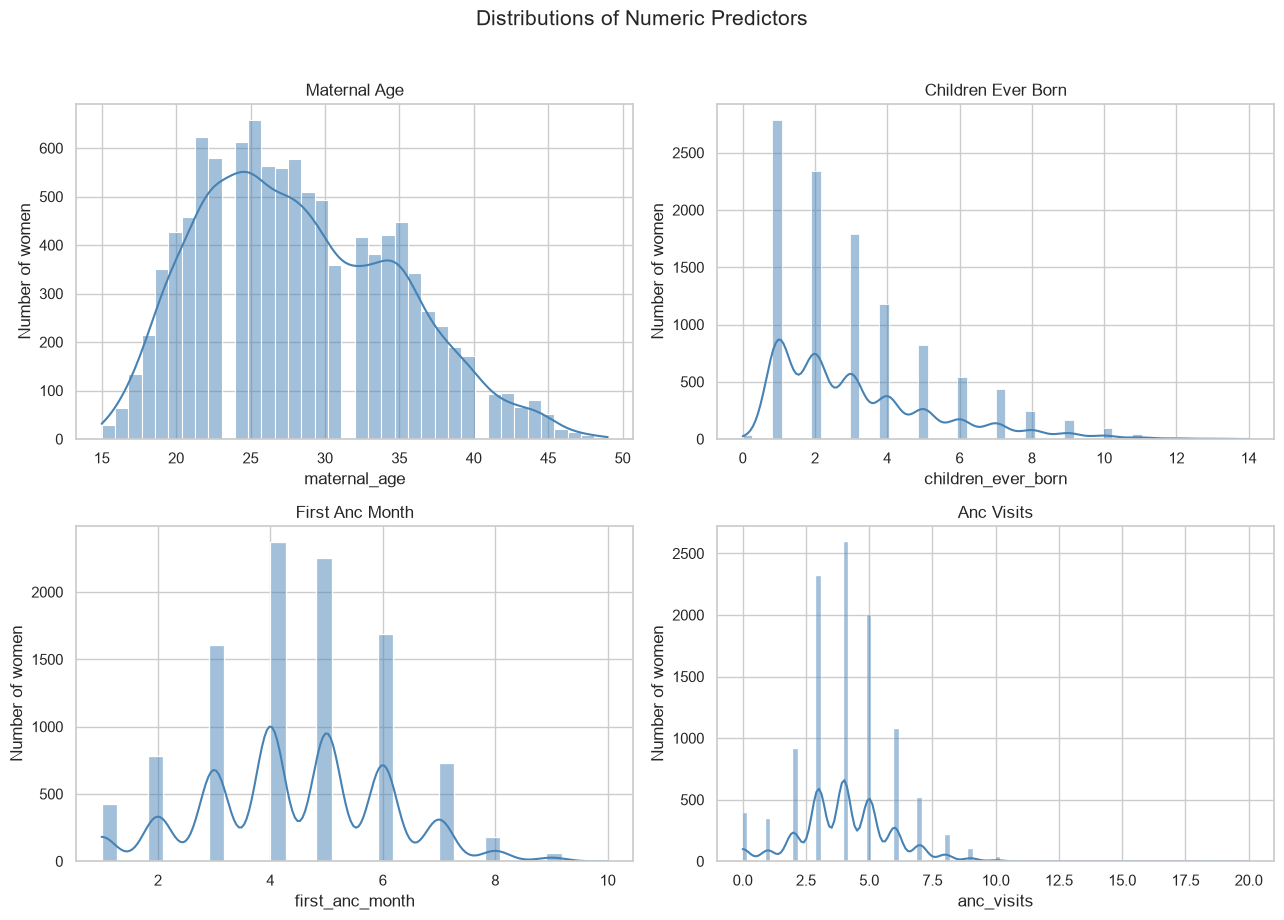

In [25]:
#numeric predictors distribution plots
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for column, axis in zip(numeric_columns, axes.flatten()):
    sns.histplot(data=eda_df, x=column, bins="auto", kde=True, ax=axis, color="steelblue")
    axis.set_title(column.replace("_", " ").title())
    axis.set_ylabel("Number of women")

plt.suptitle("Distributions of Numeric Predictors", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()



Maternal age is spread across the reproductive age range, while `children_ever_born` is right-skewed because most women have fewer children and a smaller number have high parity. ANC timing is concentrated in the earlier and middle months of pregnancy. ANC visits also show a concentration around commonly recommended attendance levels, with a smaller number of high values.

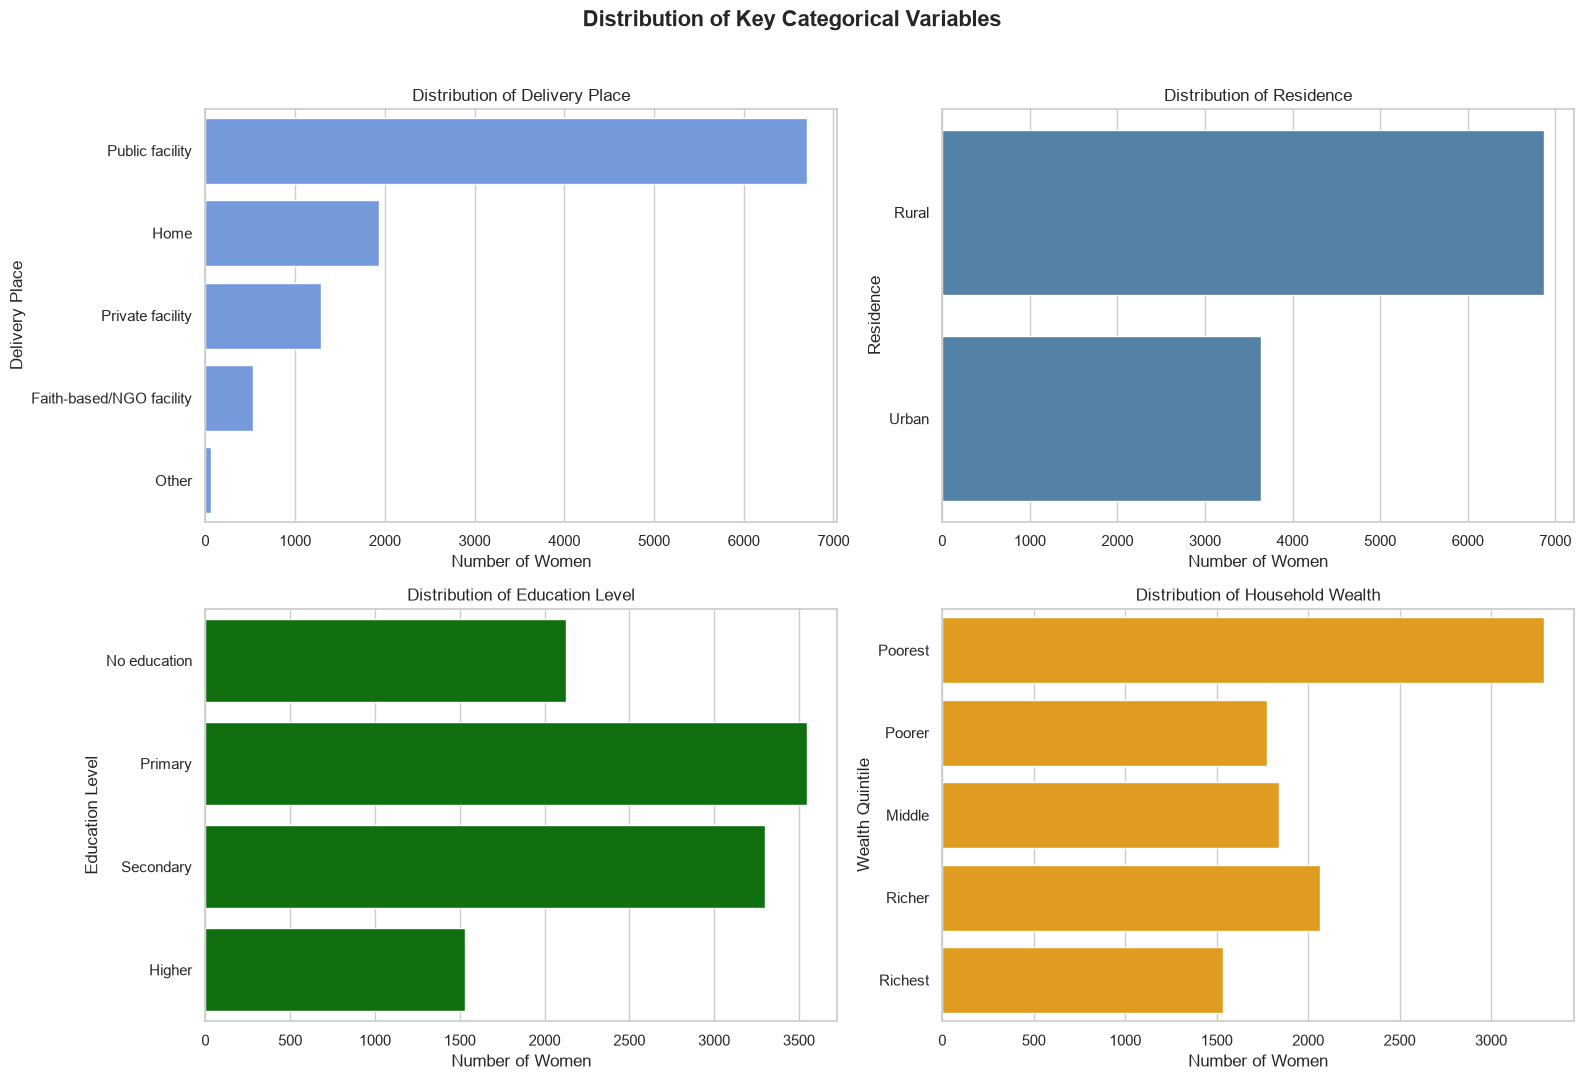

In [26]:
# categorical predictors distribution plots

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Delivery Place
delivery_counts = eda_df["delivery_place"].value_counts()

sns.barplot(
    x=delivery_counts.values,
    y=delivery_counts.index,
    color="cornflowerblue",
    ax=axes[0, 0]
)

axes[0, 0].set_title("Distribution of Delivery Place")
axes[0, 0].set_xlabel("Number of Women")
axes[0, 0].set_ylabel("Delivery Place")


# 2. Residence

residence_counts = eda_df["residence"].value_counts()

sns.barplot(
    x=residence_counts.values,
    y=residence_counts.index,
    color="steelblue",
    ax=axes[0, 1]
)

axes[0, 1].set_title("Distribution of Residence")
axes[0, 1].set_xlabel("Number of Women")
axes[0, 1].set_ylabel("Residence")


# 3. Education Level

education_order = [
    "No education",
    "Primary",
    "Secondary",
    "Higher"
]

education_counts = (
    eda_df["education_level"]
    .value_counts()
    .reindex(education_order)
)

sns.barplot(
    x=education_counts.values,
    y=education_counts.index,
    color="green",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Distribution of Education Level")
axes[1, 0].set_xlabel("Number of Women")
axes[1, 0].set_ylabel("Education Level")


# 4. Household Wealth
wealth_order = [
    "Poorest",
    "Poorer",
    "Middle",
    "Richer",
    "Richest"
]

wealth_counts = (
    eda_df["wealth_quintile"]
    .value_counts()
    .reindex(wealth_order)
)

sns.barplot(
    x=wealth_counts.values,
    y=wealth_counts.index,
    color="orange",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Distribution of Household Wealth")
axes[1, 1].set_xlabel("Number of Women")
axes[1, 1].set_ylabel("Wealth Quintile")

# Overall formatting

fig.suptitle(
    "Distribution of Key Categorical Variables",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

The distribution shows that most women delivered in **public health facilities**, while **home deliveries** and deliveries in faith-based/NGO facilities were less common. The dataset also contains more women from **rural areas** than urban areas.

For education, **primary and secondary education** account for the largest groups, while women with higher education form a smaller proportion. The wealth distribution shows representation across all five wealth quintiles, with the **poorest group** being the largest.

### 4.3 Bivariate Analysis

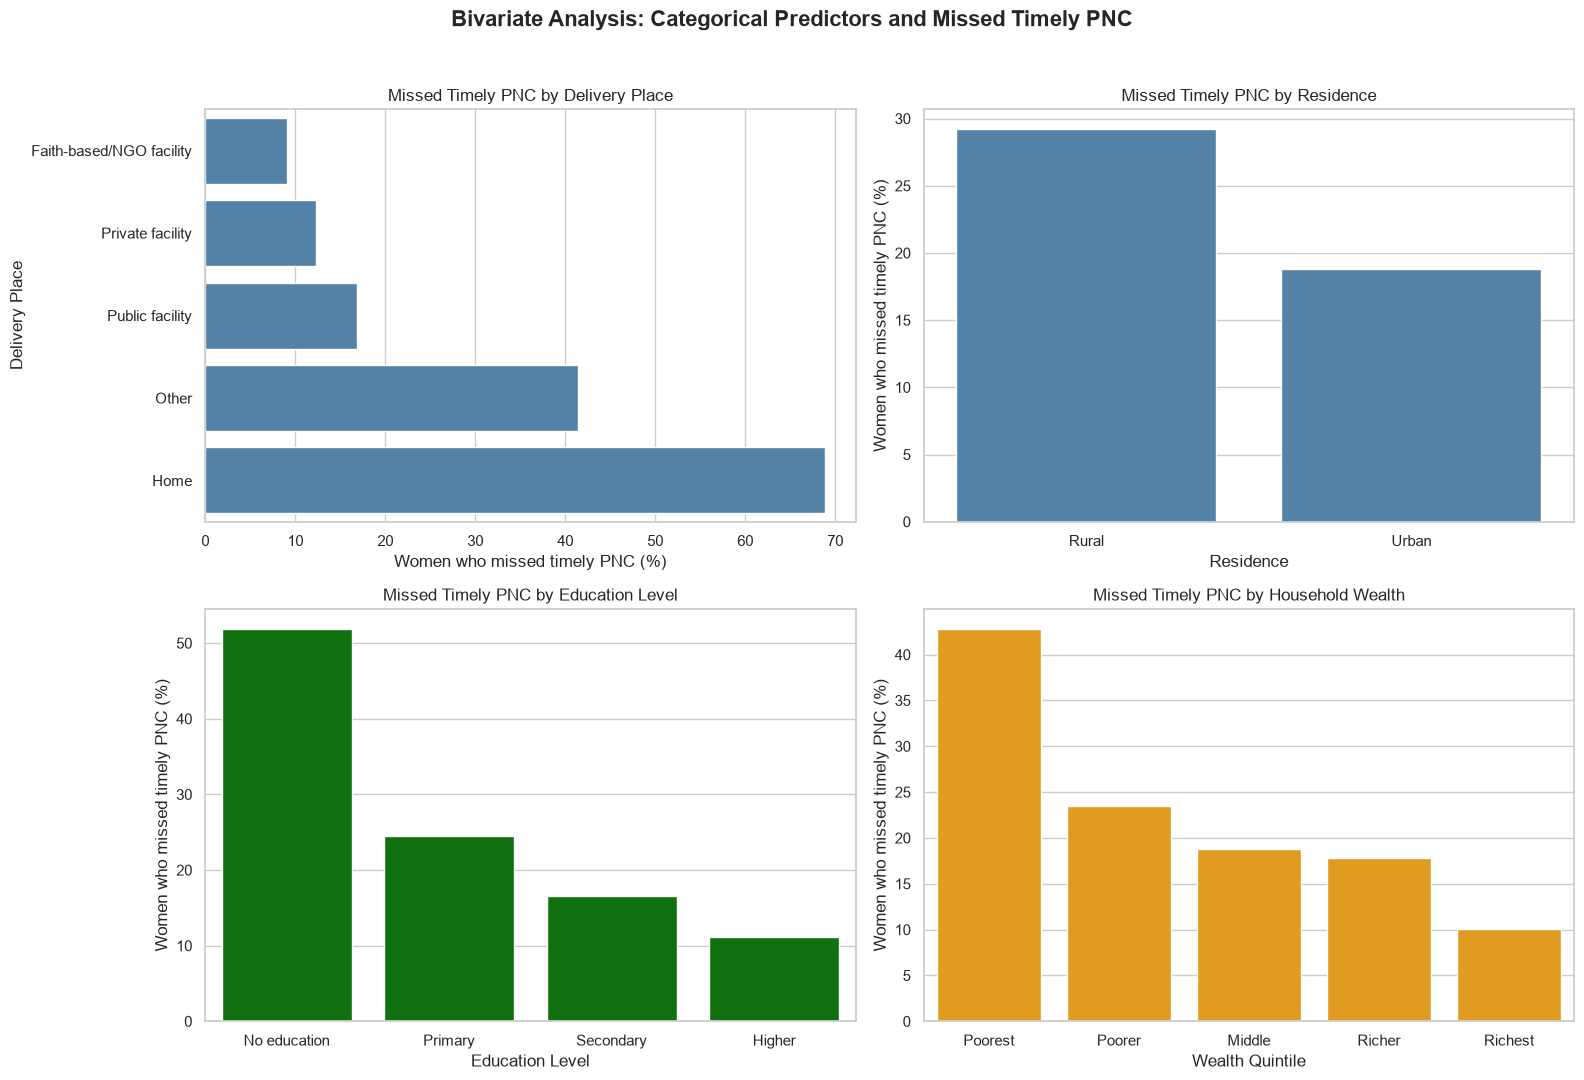

In [27]:
# Categorical Predictors vs Missed Timely PNC

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
# 1. Delivery Place vs Missed Timely PNC

delivery_rates = missed_pnc_rate(
    eda_df, "delivery_place"
).sort_values("Missed_rate_percent")

sns.barplot(
    data=delivery_rates,
    x="Missed_rate_percent",
    y="delivery_place",
    color= "steelblue",
    ax=axes[0, 0]
)

axes[0, 0].set_title("Missed Timely PNC by Delivery Place")
axes[0, 0].set_xlabel("Women who missed timely PNC (%)")
axes[0, 0].set_ylabel("Delivery Place")

# 2. Residence vs Missed Timely PNC
residence_rates = missed_pnc_rate(
    eda_df, "residence"
)

sns.barplot(
    data=residence_rates,
    x="residence",
    y="Missed_rate_percent",
    color="steelblue",
    ax=axes[0, 1]
)

axes[0, 1].set_title("Missed Timely PNC by Residence")
axes[0, 1].set_xlabel("Residence")
axes[0, 1].set_ylabel("Women who missed timely PNC (%)")


# 3. Education Level vs Missed Timely PNC

education_order = [
    "No education",
    "Primary",
    "Secondary",
    "Higher"
]

education_rates = missed_pnc_rate(
    eda_df, "education_level"
)

education_rates["education_level"] = pd.Categorical(
    education_rates["education_level"],
    categories=education_order,
    ordered=True
)

education_rates = education_rates.sort_values("education_level")

sns.barplot(
    data=education_rates,
    x="education_level",
    y="Missed_rate_percent",
    color="green",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Missed Timely PNC by Education Level")
axes[1, 0].set_xlabel("Education Level")
axes[1, 0].set_ylabel("Women who missed timely PNC (%)")


# 4. Household Wealth vs Missed Timely PNC
wealth_order = [
    "Poorest",
    "Poorer",
    "Middle",
    "Richer",
    "Richest"
]

wealth_rates = missed_pnc_rate(
    eda_df, "wealth_quintile"
)

wealth_rates["wealth_quintile"] = pd.Categorical(
    wealth_rates["wealth_quintile"],
    categories=wealth_order,
    ordered=True
)

wealth_rates = wealth_rates.sort_values("wealth_quintile")

sns.barplot(
    data=wealth_rates,
    x="wealth_quintile",
    y="Missed_rate_percent",
    color="orange",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Missed Timely PNC by Household Wealth")
axes[1, 1].set_xlabel("Wealth Quintile")
axes[1, 1].set_ylabel("Women who missed timely PNC (%)")


# Overall formatting

fig.suptitle(
    "Bivariate Analysis: Categorical Predictors and Missed Timely PNC",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

The analysis shows clear differences in missed timely PNC across several groups. **Home deliveries** have the highest missed-PNC rate, while facility deliveries have lower rates. Women in **rural areas** also show a higher missed-PNC rate than those in urban areas.

Missed timely PNC is highest among women with **no education** and decreases as education level increases. Similarly, the **poorest wealth quintile** has the highest missed-PNC rate, while the richest group has the lowest.

These findings suggest that **delivery setting, residence, education, and household wealth** may be important predictors of timely postnatal care and should be considered in the predictive modelling.

### 4.4 Multivariate Analysis

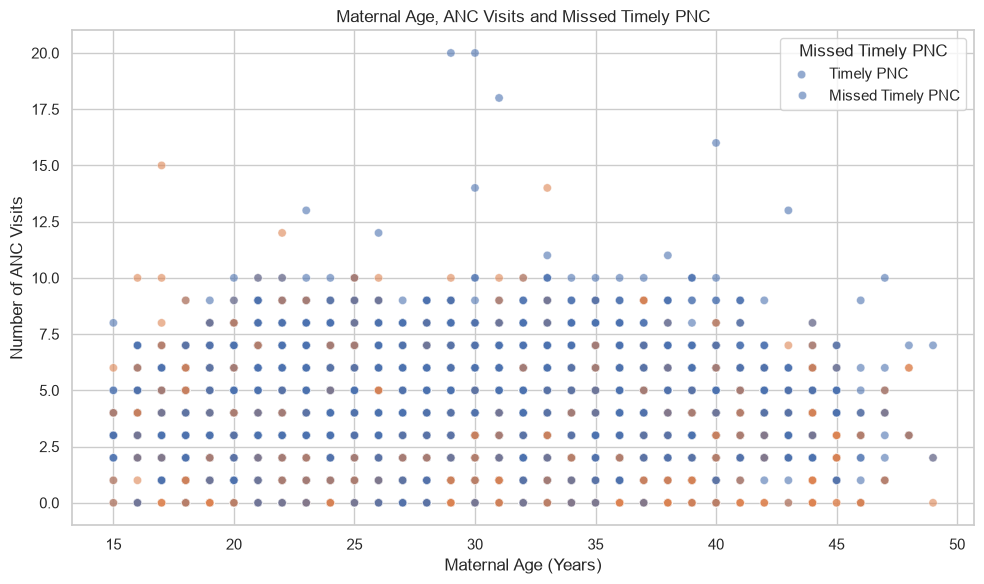

In [28]:
# Maternal Age, ANC Visits and Missed Timely PNC

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=eda_df,
    x="maternal_age",
    y="anc_visits",
    hue="missed_timely_pnc",
    alpha=0.6
)

plt.title("Maternal Age, ANC Visits and Missed Timely PNC")
plt.xlabel("Maternal Age (Years)")
plt.ylabel("Number of ANC Visits")

plt.legend(
    title="Missed Timely PNC",
    labels=["Timely PNC", "Missed Timely PNC"]
)

plt.tight_layout()
plt.show()

The plot examines maternal age and the number of ANC visits together, while distinguishing between women who received timely PNC and those who missed it.

Most observations are concentrated around **3–10 ANC visits** across different maternal ages. The plot also shows some women with very few or no ANC visits, as well as a small number with higher ANC attendance.

Overall, the distribution suggests that **maternal age and ANC attendance may provide useful information for predicting missed timely PNC**.

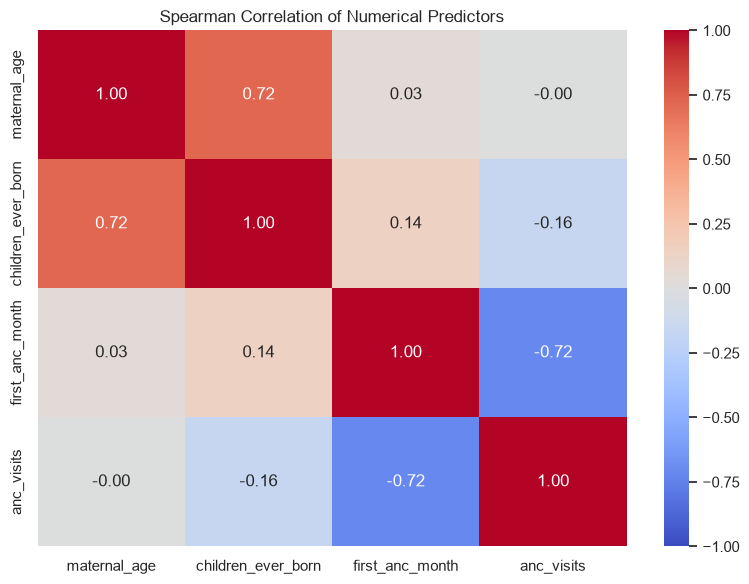

In [29]:
# Correlation Between Numerical Predictors

numeric_columns = [
    "maternal_age",
    "children_ever_born",
    "first_anc_month",
    "anc_visits"
]

correlation_matrix = eda_df[numeric_columns].corr(method="spearman")

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("Spearman Correlation of Numerical Predictors")
plt.tight_layout()
plt.show()

The Spearman correlation matrix shows a **strong positive correlation (0.72)** between maternal age and the number of children ever born, which is expected as older women generally have had more opportunities to have children.

There is also a **strong negative correlation (-0.72)** between the month of first ANC and the number of ANC visits. This suggests that women who started ANC later tended to have fewer ANC visits.

## 5. Modeling

The goal is to predict `missed_timely_pnc = 1` before the postnatal-care outcome occurs. The modelling workflow is deliberately leakage-safe:

1. Separate predictors from the target.
2. Keep an untouched 20% test set, grouped by DHS survey cluster, for final evaluation.
3. Use a validation set for model and decision-threshold selection.
4. Learn missing-value imputation and category encoding from training data only.
5. Compare a simple baseline, logistic regression, random forest, and XGBoost.

PR-AUC (average precision) is the primary model-selection metric because the missed-PNC group is the minority class.

### 5.1 Define predictors and split the data

The test set is locked away before preprocessing. Entire DHS clusters—not individual rows—are assigned to only one split. This prevents women from the same local survey cluster appearing in both training and evaluation data. Among many valid group splits, the notebook chooses one with a size and outcome prevalence closest to the requested proportions.

In [30]:
TARGET = "missed_timely_pnc"

X = model_data.drop(columns=TARGET).copy()
y = model_data[TARGET].astype(int).copy()

print(f"Predictor table: {X.shape[0]:,} rows x {X.shape[1]} columns")
print(f"Target values: {sorted(y.unique())}")

Predictor table: 10,505 rows x 13 columns
Target values: [np.int64(0), np.int64(1)]


### Data Splitting and Target Preparation

Before training our machine learning model, we need to isolate our target outcome from the independent features. 

In this step, we:
* Isolate **`missed_timely_pnc`** as our target variable ($y$) and cast it to integers for binary classification.
* Group all remaining features into our predictor matrix ($X$).
* Verify the final dimensions of our data to ensure no rows were dropped and the target classes are correctly formatted.

In [31]:
from sklearn.model_selection import GroupShuffleSplit

all_groups = visualization_data.loc[X.index, "cluster_id"]

print(f"Women: {len(X):,}")
print(f"Survey clusters: {all_groups.nunique():,}")

Women: 10,505
Survey clusters: 1,680


### Accounting for Survey Clustering (Grouped Validation)

Because our dataset originates from a clustered survey design, observations (women) sampled from the same **`cluster_id`** may exhibit spatial correlation or shared socioeconomic characteristics. 

To ensure our model generalizes well to entirely unseen communities, we will use a **Grouped Split Strategy (`GroupShuffleSplit`)**. This guarantees that:
* Entire survey clusters are kept intact during the split.
* No cluster appears in both the training and validation sets simultaneously, preventing **data leakage**.

We align our cluster tags with our filtered features ($X$) and verify the total number of independent groups available for partitioning.

In [32]:
def choose_group_split(features, target, groups, test_size, random_state):
    """Choose a cluster-separated split with a similar outcome rate."""
    splitter = GroupShuffleSplit(
        n_splits=100,
        test_size=test_size,
        random_state=random_state,
    )

    candidates = splitter.split(features, target, groups)

    def split_score(positions):
        _, held_out = positions
        size_gap = abs(len(held_out) / len(features) - test_size)
        rate_gap = abs(target.iloc[held_out].mean() - target.mean())
        return size_gap + rate_gap

    return min(candidates, key=split_score)

### Optimizing the Grouped Split (Target Balance & Size Matching)

While **`GroupShuffleSplit`** prevents data leakage by keeping entire clusters together, it introduces two challenges:
1. **Size Variance:** Because survey clusters contain unequal numbers of individuals, a random assignment of clusters can cause the final test set size to deviate significantly from our target proportion.
2. **Class Imbalance Shift:** Random cluster selection can accidentally isolate a disproportionate number of positive cases in either the train or test set, skewing our validation.

To mitigate this, we define a custom selection function, `choose_group_split`. This algorithm:
* Simulates **100 candidate splits** respecting cluster boundaries.
* Penalizes candidates whose test sets deviate from our target **sample size** or our baseline **outcome rate**.
* Selects the mathematically optimal split that minimizes these gaps, ensuring our test set is highly representative of the overall population.

In [33]:
development_positions, test_positions = choose_group_split(
    X,
    y,
    all_groups,
    test_size=0.20,
    random_state=42,
)

X_development = X.iloc[development_positions]
X_test = X.iloc[test_positions]
y_development = y.iloc[development_positions]
y_test = y.iloc[test_positions]
development_groups = all_groups.iloc[development_positions]
test_groups = all_groups.iloc[test_positions]

### Executing the Data Split

With our optimization function defined, we now execute the split to partition our data into a **Development set (80%)** and an independent **Test set (20%)**. 

The development sets (`X_development`, `y_development`) will be utilized for feature processing and nested cross-validation, while the test sets (`X_test`, `y_test`) will serve as our final "hold-out" benchmark to evaluate model generalizability. 

We also retain `development_groups` to ensure that any downstream cross-validation folds continue to respect cluster boundaries.

In [34]:
train_positions, validation_positions = choose_group_split(
    X_development,
    y_development,
    development_groups,
    test_size=0.20,
    random_state=43,
)

X_train = X_development.iloc[train_positions]
X_validation = X_development.iloc[validation_positions]
y_train = y_development.iloc[train_positions]
y_validation = y_development.iloc[validation_positions]
train_groups = development_groups.iloc[train_positions]
validation_groups = development_groups.iloc[validation_positions]

### Inner Split: Isolating Training and Validation Sets

To tune model hyperparameters and evaluate feature engineering choices without touching our final hold-out test set, we implement a **nested split** on our development data.

Using our optimized grouping logic, we divide the development set into:
* **Training Set ($X_{train}, y_{train}$):** 80% of development data, used to train candidate algorithms.
* **Validation Set ($X_{validation}, y_{validation}$):** 20% of development data, used for local performance evaluation and hyperparameter adjustments.

This nested approach mirrors our macro-splitting strategy, maintaining balanced target rates and absolute cluster separation so that no community leaks from the training set into our local validation set.

In [35]:
split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_validation), len(X_test)],
    "clusters": [
        train_groups.nunique(),
        validation_groups.nunique(),
        test_groups.nunique(),
    ],
    "missed_pnc_percent": [
        100 * y_train.mean(),
        100 * y_validation.mean(),
        100 * y_test.mean(),
    ],
}, index=["Training", "Validation", "Test"]).round(2)

display(split_summary)

assert set(X_train.index).isdisjoint(X_validation.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_validation.index).isdisjoint(X_test.index)
assert set(train_groups).isdisjoint(validation_groups)
assert set(train_groups).isdisjoint(test_groups)
assert set(validation_groups).isdisjoint(test_groups)

,rows,clusters,missed_pnc_percent
Training,6727,1075,25.64
Validation,1686,269,25.62
Test,2092,336,25.53


### Data Split Verification and Integrity Checks

To ensure the validity of our downstream modeling, we perform a rigorous quality assurance check on our partitioned datasets. 

We generate a summary table to confirm that:
1. **Target Stratification:** The percentage of missed timely postnatal care (`missed_pnc_percent`) remains stable and balanced across our Training, Validation, and Test sets.
2. **Proportional Allocation:** Sample and cluster sizes align correctly with our intentional 64/16/20 split ratio.

Additionally, we implement programmatic **`assert` statements** to guarantee absolute data isolation. These checks mathematically verify that **no individual records** and **no geographic survey clusters** overlap between any of our data partitions, completely eliminating the risk of data leakage.

### 5.2 Build leakage-safe preprocessing

Numeric missing values are filled with the training median, with an extra indicator showing that the original value was missing. Categorical gaps are filled with the most common training category and categories are one-hot encoded.

Putting these operations inside a scikit-learn pipeline ensures that validation and test information cannot influence preprocessing.

The **nine categorical predictors** are:

1. `county_name`
2. `residence`
3. `education_level`
4. `wealth_quintile`
5. `marital_status`
6. `currently_working`
7. `pregnancy_intention`
8. `delivery_place`
9. `caesarean_delivery`

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "maternal_age", "children_ever_born", "first_anc_month", "anc_visits"
]
categorical_features = [
    "county_name",
    "residence",
    "education_level",
    "wealth_quintile",
    "marital_status",
    "currently_working",
    "pregnancy_intention",
    "delivery_place",
    "caesarean_delivery",
]

assert len(numeric_features) == 4
assert len(categorical_features) == 9
assert set(numeric_features + categorical_features) == set(X.columns)

numeric_preprocessing = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
])

categorical_preprocessing = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_preprocessing, numeric_features),
    ("categorical", categorical_preprocessing, categorical_features),
], verbose_feature_names_out=False)

print(f"Numeric predictors:     {len(numeric_features)}")
print(f"Categorical predictors: {len(categorical_features)}")

Numeric predictors:     4
Categorical predictors: 9


### Feature Preprocessing and Transformations Pipeline

To ensure our features are mathematically compatible with our machine learning algorithms, we must explicitly transform them while protecting against data leakage. 

We map our indicators into two distinct types: **Continuous (Numeric)** and **Nominal (Categorical)**. We implement an explicit coverage check to confirm that 100% of our feature columns are accounted for.

We construct separate processing strategies using scikit-learn **`Pipelines`**:
* **Numeric Features Pipeline:** Missing records are imputed using column **medians**. We include a missingness indicator flag to capture potential structural non-responses. Features are then standardized to a uniform scale (**`StandardScaler`**).
* **Categorical Features Pipeline:** Missing attributes are imputed using the column **mode**. Variables are then converted into sparse binary matrices via **One-Hot Encoding**, with safeguards activated to ignore completely unseen categories during test evaluation.

Finally, we bundle these strategies into a single **`ColumnTransformer`** object (`preprocessor`). This clean abstraction will allow us to seamlessly transform our training, validation, and test datasets identically.

### 5.3 Compare baseline models

- **Dummy classifier:** provides the minimum reference point.
- **Logistic regression:** gives a transparent linear baseline.
- **Random forest:** captures nonlinear relationships and interactions.
- **XGBoost:** provides a regularized boosted-tree model for tabular data.

Class weighting gives more attention to women in the smaller missed-PNC class.

In [37]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Positive-class weight used by XGBoost: {scale_pos_weight:.2f}")

Positive-class weight used by XGBoost: 2.90


### Mitigating Class Imbalance via Cost-Sensitive Learning

Because missing timely postnatal care (`missed_timely_pnc = 1`) is typically a minority occurrence compared to standard care delivery, our training labels are likely heavily skewed. Standard classifiers trained on imbalanced profiles often optimize for global accuracy, resulting in high false-negative rates for the crucial minority class.

To counteract this, we will implement cost-sensitive learning within our **XGBoost** model using its **`scale_pos_weight`** parameter. 

We mathematically calculate the exact ratio of negative-to-positive cases in our training partition ($y_{train}$). Passing this inverse ratio to the algorithm ensures that the model penalizes misclassifying a woman who missed timely care proportionally higher, shifting the optimization focus toward maximizing **Recall** and minority class identification.

In [38]:
dummy_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DummyClassifier(strategy="prior")),
])

logistic_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        max_iter=2_000,
        class_weight="balanced",
        random_state=42,
    )),
])

### Establishing Baseline Classifiers

To evaluate the predictive power of our feature engineering and downstream complex algorithms, we must establish rigorous benchmarks. We initialize two baseline frameworks using scikit-learn **`Pipelines`**:

1. **Naive Baseline (`DummyClassifier`)**: Configured with the `prior` strategy, this model makes predictions based solely on the raw class distribution of the training data. It represents the lowest acceptable performance threshold (the "floor") that any real machine learning model must beat.
2. **Interpretability Baseline (`LogisticRegression`)**: A traditional parametric linear model used as our standard benchmark. We apply `class_weight="balanced"` to structurally penalize minority class errors and increase `max_iter` to ensure mathematical convergence during optimization.

Both models directly consume our unified `preprocessor` block, guaranteeing that preprocessing steps remain entirely isolated within each modeling pipeline.

In [39]:
random_forest_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=250,
        max_depth=12,
        min_samples_leaf=10,
        class_weight="balanced_subsample",
        n_jobs=1,
        random_state=42,
    )),
])

### Implementing a Non-Linear Ensemble Baseline (Random Forest)

To account for potential non-linear relationships and intricate feature interactions that traditional linear models might miss, we introduce a **Random Forest Classifier** pipeline. 

Our configuration emphasizes structural regularization and dynamic class balancing:
* **Ensemble Depth & Splitting Constraints:** We build **250 estimators** restricted to a `max_depth` of 12 and a minimum leaf size of 10. These parameters explicitly constrain model capacity to protect against overfitting.
* **Dynamic Imbalance Correction (`balanced_subsample`):** Rather than applying static inverse frequency weights globally, this option dynamically recalibrates class weights based on the localized class distribution within each tree's unique bootstrap sample.

This adds a powerful non-linear benchmark to our evaluation suite alongside our naive and logistic baselines.

In [40]:
xgboost_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=1,
    )),
])

Our final candidate architecture utilizes an **Extreme Gradient Boosting (XGBoost)** classifier. Unlike random forests that build deep trees in parallel, XGBoost builds a sequential chain of shallow trees, with each iteration explicitly optimizing for the residuals (errors) of the previous step.

To prevent overfitting on our survey data, we implement a highly regularized, conservative training profile:
* **Shallow Complexities:** We restrict `max_depth` to 3 and set `min_child_weight` to 5 to avoid overfitting on hyper-local cluster noise.
* **Stochastic Feature & Sample Subsampling:** Each tree only accesses 80% of rows (`subsample`) and 80% of columns (`colsample_bytree`), creating a highly generalized ensemble.
* **Shrinkage & Boosting Length:** A low `learning_rate` of 0.05 is paired with 300 estimators to ensure gradual, stable optimization.
* **Imbalance Compensation:** We integrate our pre-computed `scale_pos_weight` multiplier directly into the objective function to skew penalization favor toward the minority class.

This completes our model definition suite. We are now ready to fit, evaluate, and compare all candidate architectures.

In [41]:
models = {
    "Dummy": dummy_model,
    "Logistic regression": logistic_model,
    "Random forest": random_forest_model,
    "XGBoost": xgboost_model,
}

comparison_rows = []
fitted_models = {}

for name, estimator in models.items():
    estimator.fit(X_train, y_train)
    probabilities = estimator.predict_proba(X_validation)[:, 1]
    fitted_models[name] = estimator
    comparison_rows.append({
        "model": name,
        "validation_pr_auc": average_precision_score(y_validation, probabilities),
        "validation_roc_auc": roc_auc_score(y_validation, probabilities),
    })

model_comparison = pd.DataFrame(comparison_rows).sort_values(
    "validation_pr_auc", ascending=False
).reset_index(drop=True)

display(model_comparison.style.format({
    "validation_pr_auc": "{:.3f}",
    "validation_roc_auc": "{:.3f}",
}))

,model,validation_pr_auc,validation_roc_auc
0,XGBoost,0.600,0.780
1,Random forest,0.597,0.773
2,Logistic regression,0.594,0.778
3,Dummy,0.256,0.500


### Model Training and Validation Performance Comparison

With our candidate pipelines initialized and our dataset safely partitioned to prevent leakage, we now execute the core training and cross-evaluation loop. 

For each architecture (Dummy, Logistic Regression, Random Forest, and XGBoost), this process:
1. Fits the entire preprocessing and model pipeline exclusively using the training set ($X_{train}, y_{train}$).
2. Generates continuous prediction risk probabilities using the localized, cluster-isolated validation set ($X_{validation}$).
3. Caches the fully trained pipeline into a dictionary for downstream analysis and final test deployment.

To determine our champion model, we compile a performance leaderboard sorted primarily by **Precision-Recall Area Under the Curve (PR-AUC)**, alongside traditional **ROC-AUC**. Because our target variable is imbalanced, PR-AUC serves as our critical metric, as it more accurately reflects the model's ability to identify high-risk individuals who missed timely postnatal care without inflating false alarms.

### 5.4 Tune logistic regression and XGBoost, then select the final candidate

Cluster-aware cross-validation tunes logistic regression and XGBoost using the training set only. The tuned models and random forest are then compared on the validation set. The test set remains untouched.

In [42]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedGroupKFold

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

### Transitioning to Robust Cross-Validation (StratifiedGroupKFold)

To obtain a more stable, variance-reduced estimate of our models' predictive performance, we move away from a single train/validation split and implement a **5-Fold Cross-Validation** strategy.

We choose **`StratifiedGroupKFold`** to solve two structural challenges in our survey data simultaneously:
1. **Cluster Isolation (Grouping):** It guarantees that entire survey clusters (`cluster_id`) are kept strictly intact. A cluster will only ever appear in the training folds or the validation fold, completely preventing spatial data leakage.
2. **Class Balance (Stratification):** Standard grouped splits can cause severe fluctuations in the target rate across folds when the positive class is rare. This splitter mathematically optimizes fold assignments so that the proportion of women who missed timely postnatal care remains highly consistent across all 5 evaluation iterations.

By shuffling the data and locking in a `random_state`, we ensure our cross-validation splits are robust, uniform, and fully reproducible.

In [43]:
logistic_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        max_iter=2_000,
        class_weight="balanced",
        random_state=42,
    )),
])

logistic_tuning = GridSearchCV(
    logistic_pipeline,
    param_grid={"model__C": [0.01, 0.1, 1.0, 10.0]},
    scoring="average_precision",
    cv=cv,
    n_jobs=1,
    refit=True,
)
logistic_tuning.fit(X_train, y_train, groups=train_groups)
tuned_logistic = logistic_tuning.best_estimator_

### Hyperparameter Tuning: Optimizing the Logistic Regression Model

To ensure our Logistic Regression baseline performs at its absolute mathematical ceiling, we implement an automated **Grid Search Cross-Validation (`GridSearchCV`)** to optimize its regularization profile.

We evaluate the inverse regularization parameter, **`C`**, across a logarithmic scale spanning four orders of magnitude (`[0.01, 0.1, 1.0, 10.0]`). This allows us to control the trade-off between model simplicity and training fit:
* **Optimization Target:** We target **Average Precision (PR-AUC)** as our optimization score, aligning the tuning engine with our goal of identifying the minority class accurately.
* **Validation Rigour:** The search utilizes our cluster-aware **`StratifiedGroupKFold`** splitter (`cv`), passing `train_groups` to ensure that spatial cluster validation boundaries are strictly maintained throughout every cross-validation fold.

Following the search, the algorithm automatically executes a full **`refit`** using the winning parameter configuration across the entire training partition, which we extract as our optimized `tuned_logistic` pipeline asset.

In [44]:
xgboost_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=1,
    )),
])

### Preparing the XGBoost Pipeline Architecture for Fine-Tuning

To systematically optimize our primary champion architecture, we instantiate an unconfigured **XGBoost Pipeline** template (`xgboost_pipeline`). 

Unlike our initial baseline exploration where we used static, hardcoded parameters, this skeleton setup isolates structural parameters so they can be discovered algorithmically during a hyperparameter sweep. 

We lock in several non-negotiable operational presets:
* **Cost-Sensitive Learning:** We fix the `scale_pos_weight` setting to maintain proper minority class penalties across all parameter permutations.
* **Algorithmic Consistency:** We anchor our optimization tracking to `logloss` and assign a static `random_state` to ensure that fluctuations in downstream performance metrics are driven solely by hyperparameter alterations, not internal stochastic noise.

In [45]:
xgboost_parameters = {
    "model__n_estimators": [200, 300, 400],
    "model__max_depth": [2, 3, 4],
    "model__learning_rate": [0.03, 0.05, 0.08],
    "model__min_child_weight": [1, 5, 10],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__reg_alpha": [0.0, 0.01, 0.1, 1.0],
    "model__reg_lambda": [0.5, 1.0, 1.5, 2.0],
    "model__gamma": [0.0, 0.1, 0.5],
}

print(f"XGBoost parameter groups: {len(xgboost_parameters)}")
print("Random search will evaluate 20 configurations across 5 folds (100 fits).")

XGBoost parameter groups: 9
Random search will evaluate 20 configurations across 5 folds (100 fits).


### Configuring the Tuning Search Space for XGBoost

To maximize the predictive performance of our champion XGBoost model, we define a robust hyperparameter grid (`xgboost_parameters`) spanning several key dimensions of tree boosting theory:

1. **Model Capacity & Architecture:** Tuning `n_estimators`, `max_depth`, and `min_child_weight` allows us to control individual tree complexity and determine how deep or wide our sequential model should grow.
2. **Optimization Rate:** Adjusting `learning_rate` helps find the inflection point where small updates smoothly minimize our objective function without overshooting.
3. **Stochastic Regularization:** By varying row (`subsample`) and feature (`colsample_bytree`) sampling rates, we force individual trees to learn complementary, uncorrelated patterns.
4. **Structural Penalization:** We incorporate explicit mathematical penalties via $L_1$ lasso (`reg_alpha`), $L_2$ ridge (`reg_lambda`), and a split threshold (`gamma`) to aggressively push down model weights that capitalize on data noise.

Given that a brute-force Grid Search across all variations would be computationally prohibitive, we configure a **Randomized Search (`RandomizedSearchCV`)**. This strategy will randomly sample 20 distinct candidate configurations across our 5-fold cross-validation scheme—executing 100 fits to locate an optimal model parameter setup efficiently.

In [46]:
xgboost_tuning = RandomizedSearchCV(
    xgboost_pipeline,
    param_distributions=xgboost_parameters,
    n_iter=20,
    scoring="average_precision",
    cv=cv,
    n_jobs=1,
    random_state=42,
    refit=True,
)
xgboost_tuning.fit(X_train, y_train, groups=train_groups)
tuned_xgboost = xgboost_tuning.best_estimator_

### Executing the Randomized Hyperparameter Search for XGBoost

To identify the ideal regularization and growth settings for our champion XGBoost model, we run an automated **Randomized Search Cross-Validation (`RandomizedSearchCV`)**.

Rather than exhaustively scanning every potential parameter combination, which would be computationally restrictive, we randomly sample **20 candidate configurations** from our parameter distribution. This approach balances runtime efficiency with broad optimization coverage.

Our optimization setup operates under the following criteria:
* **Metric Alignment:** We evaluate performance using **Average Precision (PR-AUC)** to prioritize minority-class identification over naive overall accuracy.
* **Cluster Validation Framework:** Each candidate is assessed across our 5-fold **`StratifiedGroupKFold`** strategy (`cv`), passing `train_groups` to ensure spatial boundaries are strictly enforced and zero data leaks across folds.
* **Automated Refitting:** Once the optimal parameter candidate is isolated, `refit=True` ensures the winning configuration is completely retrained on the entire training set ($X_{train}$). 

The final, optimized pipeline is extracted and cached as `tuned_xgboost` for comparative model evaluation.

In [47]:
selection_candidates = {
    "Tuned logistic regression": tuned_logistic,
    "Random forest": fitted_models["Random forest"],
    "Tuned XGBoost": tuned_xgboost,
}

selection_rows = []
for name, estimator in selection_candidates.items():
    probabilities = estimator.predict_proba(X_validation)[:, 1]
    selection_rows.append({
        "model": name,
        "validation_pr_auc": average_precision_score(y_validation, probabilities),
    })

selection_table = pd.DataFrame(selection_rows).sort_values(
    "validation_pr_auc", ascending=False
)
display(selection_table.style.format({"validation_pr_auc": "{:.3f}"}))

,model,validation_pr_auc
2,Tuned XGBoost,0.600
1,Random forest,0.597
0,Tuned logistic regression,0.594


After systematically tuning our hyperparameter frameworks, we conduct a final comparative review to declare our champion model. 

We gather our top-performing architectures—**Tuned Logistic Regression**, **Tuned XGBoost**, and our competitive baseline **Random Forest**—and evaluate them on our independent validation partition ($X_{validation}, y_{validation}$). Because this validation block was isolated from the hyperparameter search engines, it serves as an unbiased testbed.

We evaluate the models using **Precision-Recall Area Under the Curve (PR-AUC)** to measure how reliably each model assigns high-risk probabilities to the rare minority class (women who missed timely postnatal care). The model that secures the top spot on this leaderboard will be officially chosen as our champion architecture for final test set validation.

In [48]:
selected_model_name = selection_table.iloc[0]["model"]
best_model = selection_candidates[selected_model_name]
validation_probabilities = best_model.predict_proba(X_validation)[:, 1]

if selected_model_name == "Tuned XGBoost":
    selected_best_parameters = xgboost_tuning.best_params_
elif selected_model_name == "Tuned logistic regression":
    selected_best_parameters = logistic_tuning.best_params_
else:
    selected_best_parameters = fitted_models["Random forest"].named_steps["model"].get_params()

print(f"Best logistic CV PR-AUC: {logistic_tuning.best_score_:.3f}")
print(f"Best XGBoost CV PR-AUC:  {xgboost_tuning.best_score_:.3f}")
print(f"Selected model: {selected_model_name}")
print(f"Validation PR-AUC: {average_precision_score(y_validation, validation_probabilities):.3f}")
display(pd.Series(selected_best_parameters, name="value").to_frame())

Best logistic CV PR-AUC: 0.657
Best XGBoost CV PR-AUC:  0.657
Selected model: Tuned XGBoost
Validation PR-AUC: 0.600


,value
model__subsample,0.80
model__reg_lambda,1.00
model__reg_alpha,0.00
model__n_estimators,400.00
model__min_child_weight,10.00
model__max_depth,3.00
model__learning_rate,0.03
model__gamma,0.00
model__colsample_bytree,1.00


Following our comparative validation review, we programmatically isolate the top-performing architecture from our leaderboard to serve as our **Champion Model**. 

By avoiding a hardcoded selection, this logic dynamically extracts the pipeline that achieved the highest Precision-Recall Area Under the Curve (PR-AUC). This step automatically pulls the model's underlying configuration, extracts its winning hyperparameter blueprint, and outputs a diagnostic summary comparing our cross-validation tuning scores against the independent validation set.

Reviewing this final parameter profile ensures full reproducibility and allows us to verify that our regularization thresholds (such as tree constraints or penalty strengths) are mathematically sound before we deploy this model to the final hold-out test set.

### 5.5 Select an operating threshold

The default threshold of 0.50 is not automatically best for a maternal-health screening tool. We select the threshold that maximizes the F2 score on validation data. F2 gives recall more weight than precision, reflecting the higher cost of failing to flag a woman who may miss timely PNC.

The test set is not used to choose this threshold.

In [49]:
from sklearn.metrics import precision_recall_curve

validation_precision, validation_recall, validation_thresholds = precision_recall_curve(
    y_validation, validation_probabilities
)
beta_squared = 4
validation_f2 = (
    (1 + beta_squared) * validation_precision * validation_recall
    / (beta_squared * validation_precision + validation_recall + 1e-12)
)

best_threshold_index = int(np.nanargmax(validation_f2[:-1]))
decision_threshold = float(validation_thresholds[best_threshold_index])

print(f"Selected probability threshold: {decision_threshold:.3f}")
print(f"Validation precision: {validation_precision[best_threshold_index]:.3f}")
print(f"Validation recall:    {validation_recall[best_threshold_index]:.3f}")
print(f"Validation F2:        {validation_f2[best_threshold_index]:.3f}")

Selected probability threshold: 0.278
Validation precision: 0.332
Validation recall:    0.912
Validation F2:        0.676


### Decision Threshold Optimization via $F_2$-Score Maximization

Up to this point, our models have generated continuous probability risk scores. To translate these raw probabilities into binary clinical actions (e.g., flagging a patient for targeted outreach), we must establish an optimal **decision threshold**. 

Instead of using the arbitrary default threshold of 0.50, we analytically determine a threshold tailored to our public health objective. In this scenario, **Recall** is our critical priority: missing a woman who is at risk of skipping timely postnatal care (a False Negative) carries a severe clinical cost, whereas reaching out to a woman who would have attended anyway (a False Positive) is a minor resource expense.

To mathematically codify this priority, we maximize the **$F_2$-score** across our validation precision-recall curve. The $F_2$ metric weights recall twice as heavily as precision. Below, we calculate the $F_2$-score at every potential threshold boundary, isolate the peak operational index, and extract the customized probability threshold that optimizes our intervention's real-world impact.

## 6. Evaluation

The selected model and threshold are now evaluated once on the untouched test set. PR-AUC measures ranking quality across all thresholds, while recall, precision, F2, and the confusion matrix describe performance at the chosen operating threshold.

### 6.1 Final test metrics

In [50]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    fbeta_score,
    precision_score,
    recall_score,
)

test_probabilities = best_model.predict_proba(X_test)[:, 1]
test_predictions = (test_probabilities >= decision_threshold).astype(int)

test_metrics = pd.Series({
    "PR-AUC": average_precision_score(y_test, test_probabilities),
    "ROC-AUC": roc_auc_score(y_test, test_probabilities),
    "Recall": recall_score(y_test, test_predictions, zero_division=0),
    "Precision": precision_score(y_test, test_predictions, zero_division=0),
    "F2": fbeta_score(y_test, test_predictions, beta=2, zero_division=0),
    "Balanced accuracy": balanced_accuracy_score(y_test, test_predictions),
    "Accuracy": accuracy_score(y_test, test_predictions),
    "Brier score (lower is better)": brier_score_loss(y_test, test_probabilities),
}, name="test_value")

display(test_metrics.to_frame().style.format("{:.3f}"))
print("Classification report:")
print(classification_report(
    y_test,
    test_predictions,
    target_names=["Timely PNC", "Missed timely PNC"],
    zero_division=0,
))

,test_value
PR-AUC,0.648
ROC-AUC,0.805
Recall,0.897
Precision,0.337
F2,0.674
Balanced accuracy,0.647
Accuracy,0.524
Brier score (lower is better),0.166


Classification report:
                   precision    recall  f1-score   support

       Timely PNC       0.92      0.40      0.55      1558
Missed timely PNC       0.34      0.90      0.49       534

         accuracy                           0.52      2092
        macro avg       0.63      0.65      0.52      2092
     weighted avg       0.77      0.52      0.54      2092



### Final Model Evaluation on Locked Hold-Out Test Data

This step executes the final, definitive benchmark of our champion predictive pipeline. Up to this point, the **Test Set ($X_{test}, y_{test}$)** has remained completely isolated from feature fitting, model training, hyperparameter optimization, and threshold tuning. 

Using this unseen data partition, we:
1. Extract the continuous, out-of-sample risk probabilities.
2. Apply our optimized **`decision_threshold`** to generate binary intervention flags.
3. Compile a comprehensive evaluation suite comprising threshold-agnostic tracking (PR-AUC, ROC-AUC), cost-sensitive metrics (Recall, Precision, $F_2$), and probability calibration diagnostics (Brier Score).

These output statistics provide an unbiased assessment of the model's clinical utility and real-world generalizability for identifying women at high risk of missing timely postnatal care.

### 6.2 Check whether the model is overfitting

Overfitting happens when a model learns the training data too closely and then performs substantially worse on new data. We therefore compare the same measures on the training, validation, and test sets.

PR-AUC and ROC-AUC assess how well the model ranks higher-risk women across all possible thresholds. Recall, precision, and F2 assess decisions made using the threshold chosen from the validation set. Some difference between datasets is normal; a much stronger training result would be a warning sign.

In [51]:
def evaluate_data_split(split_name, X_split, y_split):
    """Calculate the same performance measures for one data split."""
    probabilities = best_model.predict_proba(X_split)[:, 1]
    predictions = (probabilities >= decision_threshold).astype(int)

    return {
        "Dataset": split_name,
        "PR-AUC": average_precision_score(y_split, probabilities),
        "ROC-AUC": roc_auc_score(y_split, probabilities),
        "Recall": recall_score(y_split, predictions, zero_division=0),
        "Precision": precision_score(y_split, predictions, zero_division=0),
        "F2": fbeta_score(y_split, predictions, beta=2, zero_division=0),
    }

### Creating a Standardized Evaluation Function

To evaluate our model's performance consistently across different stages of data partitioning, we implement a reusable helper function: `evaluate_data_split`. 

Rather than copying and pasting metric calculations for multiple data splits, this function provides a single source of truth for our evaluation framework. For any given subset of data, it:
* Generates continuous risk probabilities using our locked **`best_model`** pipeline.
* Binarizes those risks using our recall-optimized **`decision_threshold`**.
* Returns a standardized dictionary containing our primary metrics of interest: **PR-AUC, ROC-AUC, Recall, Precision, and $F_2$**.

In [52]:
overfitting_check = pd.DataFrame([
    evaluate_data_split("Training", X_train, y_train),
    evaluate_data_split("Validation", X_validation, y_validation),
    evaluate_data_split("Test", X_test, y_test),
]).set_index("Dataset")

display(overfitting_check.style.format("{:.3f}"))

,PR-AUC,ROC-AUC,Recall,Precision,F2
Dataset,,,,,
Training,0.695,0.841,0.932,0.359,0.706
Validation,0.600,0.780,0.912,0.332,0.676
Test,0.648,0.805,0.897,0.337,0.674


### Model Diagnostics: Overfitting and Generalizability Audit

To confirm that our champion model is robust and ready for deployment, we compile a centralized **Overfitting Check Summary**. 

By evaluating our final pipeline and optimized decision threshold across our **Training**, **Validation**, and **Test** sets simultaneously, we can directly observe how performance scales across data boundaries. We audit this table for two primary signals:
1. **Generalization Gap:** We look at the delta(<0.05) between our *Training* and *Test* scores (particularly **PR-AUC** and **Recall**). A minor, stable drop is expected, but a severe divergence indicates that the model has memorized localized noise rather than learning universal patterns.
2. **Validation Reliability:** We verify that our *Validation* set scores closely mirror our final *Test* set scores. This confirms that our cluster-isolated **`StratifiedGroupKFold`** tuning loop acted as an accurate proxy for true out-of-sample data.

This holistic overview provides the final diagnostic transparency required to validate the model's reliability.

**How to read the table:** compare each training value with the validation and test values in the same column. Similar results indicate that the model is generalizing to unseen women. If the training scores are much higher, the model may be overfitting.

In [53]:
pr_auc_gap = (
    overfitting_check.loc["Training", "PR-AUC"]
    - overfitting_check.loc["Test", "PR-AUC"]
)

print(f"Training-to-test PR-AUC gap: {pr_auc_gap:.3f}")

if pr_auc_gap < 0.05:
    print("Interpretation: little evidence of overfitting from this comparison.")
elif pr_auc_gap <= 0.10:
    print("Interpretation: some overfitting may be present and should be monitored.")
else:
    print("Interpretation: the gap suggests likely overfitting and needs investigation.")

Training-to-test PR-AUC gap: 0.046
Interpretation: little evidence of overfitting from this comparison.


**What this means:** the generalization gap summarizes how much PR-AUC falls between the training and untouched test data. As a practical guide, a gap below 0.05 provides little evidence of overfitting, 0.05–0.10 deserves monitoring, and a gap above 0.10 warrants investigation. These are useful guidelines rather than universal statistical rules, so the full comparison table should also be considered.

#### Safeguards already used to reduce overfitting

Several choices in this notebook make an overly optimistic result less likely:

- **Separate training, validation, and test sets:** the model learns from the training set, model and threshold choices use validation data, and the test set remains untouched until final evaluation.
- **Cluster-aware splitting:** women from the same sampling cluster are kept together, reducing information leakage between datasets.
- **Five-fold grouped cross-validation:** tuning evaluates each candidate across several group-aware folds instead of trusting one split.
- **Validation-based model selection:** the final model is chosen using validation PR-AUC rather than training performance.
- **Validation-based threshold selection:** the F2 decision threshold is selected without looking at test outcomes.
- **Controlled model complexity:** the XGBoost search includes limits on tree depth, minimum child weight, sampling, and regularization.
- **One-time test evaluation:** the untouched test set provides the clearest estimate of performance on new women.

The test PR-AUC being close to—or higher than—the validation PR-AUC is reassuring. It does not prove that overfitting is impossible, but it means the current evaluation does not show the usual pattern of performance collapsing on unseen data.

### 6.3 Diagnostic plots

The precision-recall curve is the most important plot for this imbalanced outcome. The ROC curve shows ranking performance, the confusion matrix shows the actual screening decisions, and the probability plot shows how clearly the model separates the two groups.

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

sns.set_theme(style="whitegrid")

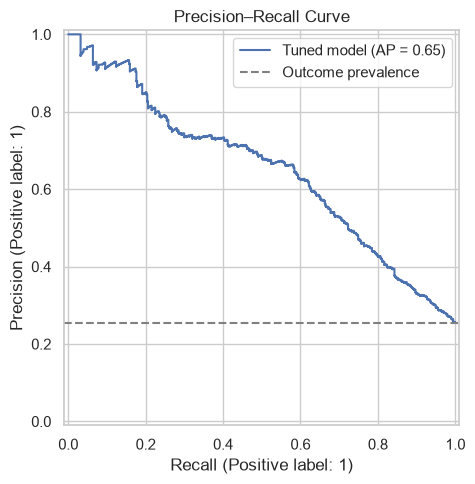

In [55]:
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(
    y_test,
    test_probabilities,
    ax=ax,
    name="Tuned model",
)
ax.axhline(y_test.mean(), color="grey", linestyle="--", label="Outcome prevalence")
ax.set_title("Precision–Recall Curve")
ax.legend()
plt.tight_layout()
plt.show()

### Model Performance Evaluation: Precision-Recall Curve Analysis

To visually audit our model's performance on our imbalanced dataset, we generate a **Precision-Recall (PR) Curve**. Unlike an ROC curve, which can paint an overly optimistic picture when the negative class dominates, the PR curve focuses strictly on the minority class of interest: women who missed timely postnatal care (`label: 1`).

Key observations from this visualization include:
* **Substantial Baseline Improvement:** The horizontal dashed line represents our **Outcome Prevalence (~25%)**, which is the performance tier of a completely random guesser. Our tuned model (blue line) dominates this baseline across all thresholds.
* **Strong Global Discrimination:** The model achieves an **Average Precision (AP) of 0.65**. This high PR-AUC confirms that the classifier maintains robust precision even as we pull the threshold down to capture more at-risk individuals.
* **Visual Justification for Threshold Tuning:** The curve reveals a smooth trade-off. By shifting our operational threshold toward the right side of the x-axis, we can significantly boost **Recall** (catching more high-risk individuals) while maintaining a precision rate that remains safely above random prevalence.

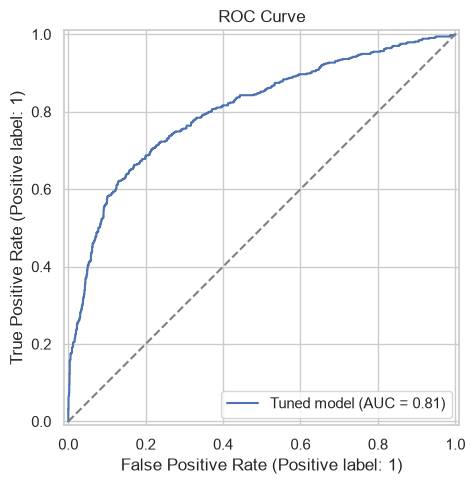

In [56]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, test_probabilities, ax=ax, name="Tuned model")
ax.plot([0, 1], [0, 1], "--", color="grey")
ax.set_title("ROC Curve")
plt.tight_layout()
plt.show()

### Model Performance Evaluation: Receiver Operating Characteristic (ROC) Curve

To evaluate our model's global sorting efficiency across the entire population, we analyze its **Receiver Operating Characteristic (ROC) Curve**. This graphic illustrates the relationship between our **True Positive Rate** (Recall) and **False Positive Rate** as we vary our operational decision boundary.

Key insights from this metric include:
* **Excellent Global Discrimination:** The model achieves an **Area Under the Curve (ROC-AUC) of 0.81**. This means that if we randomly pick one individual who missed timely postnatal care and one who attended on time, the model will correctly rank the higher-risk patient 81% of the time.
* **Steep Left-Hand Ascent:** The curve climbs rapidly on the left side of the axis, indicating that the model can successfully isolate a large block of true positive cases while accumulating very few false positives.
* **Complementary Validation:** Taken alongside our PR-AUC score of 0.65, this ROC-AUC of 0.81 provides strong evidence that our hyperparameter tuning successfully produced a generalized, high-performing classifier that avoids overfitting to noise.

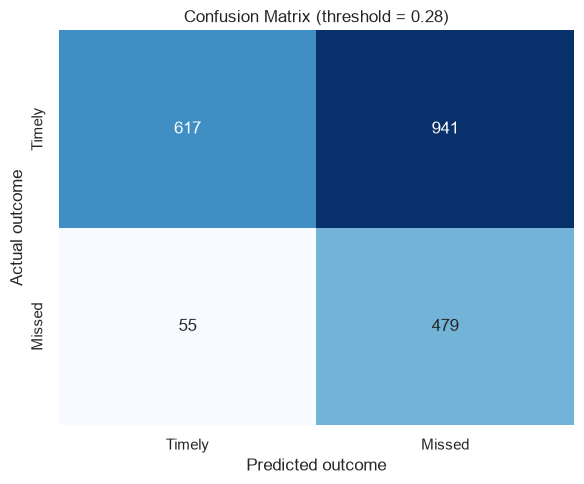

In [57]:
matrix = confusion_matrix(y_test, test_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(
    matrix,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Timely", "Missed"],
    yticklabels=["Timely", "Missed"],
)
plt.title(f"Confusion Matrix (threshold = {decision_threshold:.2f})")
plt.xlabel("Predicted outcome")
plt.ylabel("Actual outcome")
plt.tight_layout()
plt.show()

### Model Operationalization: Confusion Matrix Evaluation

To understand the concrete, real-world impact of our optimized classification boundary, we analyze the **Confusion Matrix** evaluated at our custom decision threshold of **0.28**. 

This matrix maps out the exact distribution of our predictions against actual clinical outcomes:
* **High-Stakes Sensitivity (Recall):** Out of 534 total women who actually missed timely postnatal care, our model successfully flagged **479 True Positives**, while minimizing **False Negatives to just 55**. This translates to a **Recall rate of ~89.7%**, proving that our $F_2$ optimization successfully built a strong safety net to catch high-risk patients.
* **The Operational Cost Trade-Off:** Achieving this exceptional capture rate required lowering our probability threshold, which naturally increased our **False Positives to 941**. 

In public health deployment, this profile represents an ideal compromise: the cost of a false alarm (e.g., automated SMS reminders or a routine community health worker visit) is vastly lower than the severe medical and financial consequences of failing to catch a mother who completely misses critical postnatal care.

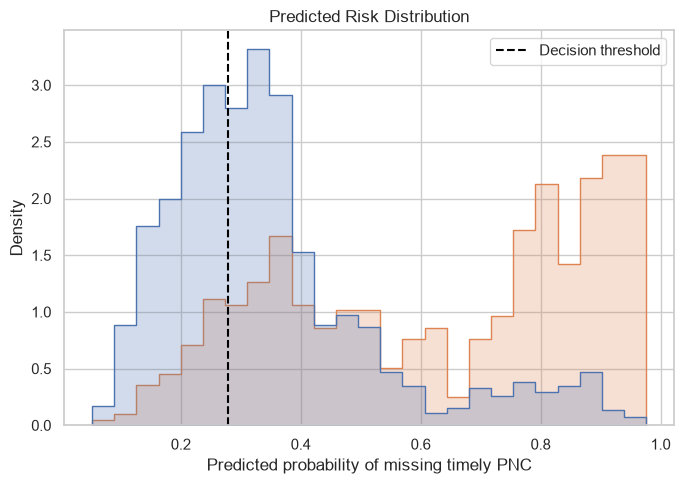

In [58]:
plt.figure(figsize=(7, 5))
sns.histplot(
    x=test_probabilities,
    hue=y_test.map({0: "Timely", 1: "Missed"}),
    bins=25,
    stat="density",
    common_norm=False,
    element="step",
)
plt.axvline(decision_threshold, color="black", linestyle="--", label="Decision threshold")
plt.title("Predicted Risk Distribution")
plt.xlabel("Predicted probability of missing timely PNC")
plt.legend()
plt.tight_layout()
plt.show()

### Visualizing Class Separation and Risk Distribution

To evaluate how confidently our model differentiates between our two patient cohorts, we analyze the **Predicted Risk Distribution** plot. This density visualization maps out the exact probability scores assigned to individuals who actually completed timely care (Blue) versus those who missed it (Orange).

Key structural takeaways from this distribution include:
* **Bimodal Polarization:** The model displays strong discriminative capacity. It successfully pushes a large volume of the actual missed care cohort (Orange) toward the extreme right end of the spectrum ($>0.75$) while clustering the timely care cohort (Blue) on the lower end ($<0.40$).
* **Anatomy of the Threshold (0.28 Split):** Slicing the model predictions at our optimized $F_2$ threshold of **0.28** visually demonstrates our risk-tolerant intervention strategy. 
* **Visualizing the Trade-off:** By positioning our vertical boundary at 0.28, we ensure that nearly the entire orange mass falls to the right side of the fence, securing our **~89.7% Recall**. The trade-off is equally visible: we cut directly through the right shoulder of the blue distribution, which explains the accumulation of false positives seen in our matrix.

This visualization confirms that our model's probabilities are well-behaved and that the underlying classifier is actively finding strong, distinct features to separate high-risk and low-risk mothers.

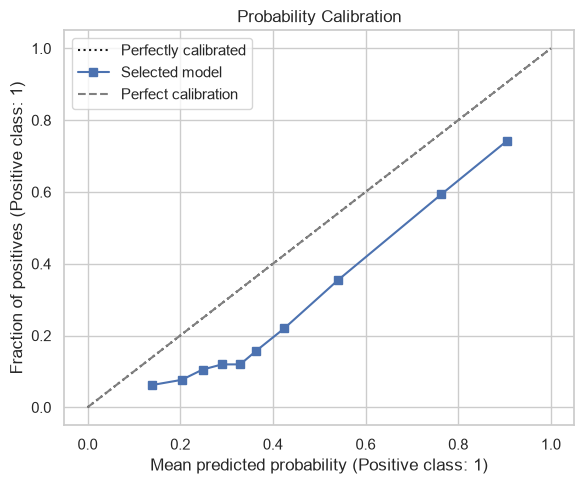

In [59]:
fig, ax = plt.subplots(figsize=(6, 5))
CalibrationDisplay.from_predictions(
    y_test,
    test_probabilities,
    n_bins=10,
    strategy="quantile",
    ax=ax,
    name="Selected model",
)
ax.plot([0, 1], [0, 1], "--", color="grey", label="Perfect calibration")
ax.set_title("Probability Calibration")
ax.legend()
plt.tight_layout()
plt.show()

### Probability Calibration and Reliability Analysis

To evaluate whether our model's continuous risk scores can be interpreted as literal, real-world probabilities, we examine the **Probability Calibration Curve**. 

Key insights from this reliability diagnostic include:
* **Systematic Risk Overestimation:** Our selected model (blue line) runs consistently below the reference diagonal line of **Perfect Calibration**. This indicates that the pipeline systematically overestimates the probability of an individual missing timely postnatal care (e.g., a predicted risk of 55% corresponds to an actual observed positive rate of roughly 35%).
* **The Cost of Class Balancing:** This uncalibrated behavior is the expected mathematical trade-off of our cost-sensitive learning approach. Utilizing structural adjustments like `scale_pos_weight` and balanced class weights intentionally shifts the probability distribution upward to maximize minority class detection (**Recall**).
* **Operational Implication:** While the model retains excellent discriminative alignment (as demonstrated by our ROC-AUC of 0.81), stakeholders should treat these outputs as **relative risk scores** rather than absolute absolute probabilities. If true absolute probabilities are strictly required for resource allocation downstream, an explicit post-processing calibration technique (such as *Isotonic Regression*) should be appended.

### 6.4 Explain the model with permutation importance

Permutation importance measures how much test PR-AUC falls when one predictor is randomly shuffled. A larger decrease means the model relied more strongly on that predictor. This explains predictive reliance, not causation.

,predictor,importance_mean,importance_std
0,delivery_place,0.2691,0.0054
1,county_name,0.0766,0.0039
2,caesarean_delivery,0.0073,0.0011
3,wealth_quintile,0.0059,0.0007
4,marital_status,0.0020,0.0003
5,currently_working,0.0012,0.0009
6,residence,0.0010,0.0008
7,pregnancy_intention,0.0008,0.0019
8,education_level,0.0003,0.0019
9,maternal_age,-0.0002,0.0008


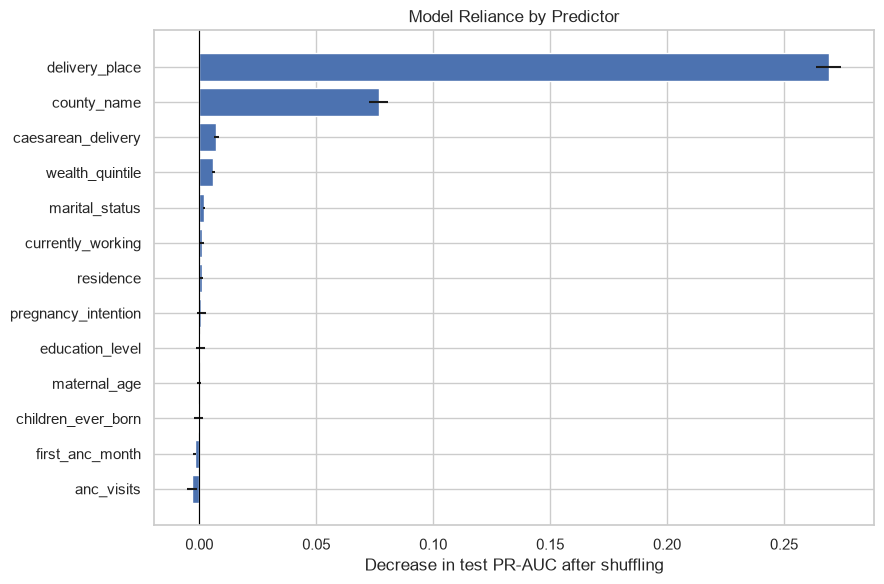

In [60]:
from sklearn.inspection import permutation_importance

importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=2,
    random_state=42,
    n_jobs=1,
)

importance_table = (
    pd.DataFrame({
        "predictor": X_test.columns,
        "importance_mean": importance.importances_mean,
        "importance_std": importance.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

display(importance_table.style.format({
    "importance_mean": "{:.4f}",
    "importance_std": "{:.4f}",
}))

plot_data = importance_table.sort_values("importance_mean")
plt.figure(figsize=(9, 6))
plt.barh(
    plot_data["predictor"],
    plot_data["importance_mean"],
    xerr=plot_data["importance_std"],
    color="#4C72B0",
)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Decrease in test PR-AUC after shuffling")
plt.title("Model Reliance by Predictor")
plt.tight_layout()
plt.show()

To transition our model from a "black box" predictor into an actionable public health tool, we must understand which factors drive its risk assessments. We implement **Permutation Feature Importance** using our final test partition ($X_{test}, y_{test}$).

Unlike traditional tree-based importance metrics—which inherently over-value high-cardinality continuous variables—permutation importance is model-agnostic and directly linked to true out-of-sample performance. The algorithm operates through a straightforward experiment:
1. It breaks the relationship between a single predictor and our target by randomly shuffling that feature's column values, effectively turning it into random noise.
2. It re-evaluates our champion pipeline on this altered data and records the resulting drop in **Average Precision (PR-AUC)**.
3. It repeats this process across multiple iterations to measure stability.

A substantial drop in PR-AUC indicates that the model relies heavily on that feature to identify high-risk individuals. Below, we tabulate these performance impacts and generate a horizontal bar chart complete with error bars to isolate our most critical predictive drivers.

### 6.5 Explain XGBoost predictions with SHAP


### Advanced Model Interpretation: Global and Local SHAP Analysis

While permutation importance isolates which variables dictate overall out-of-sample performance, it cannot illustrate the directional mechanics of individual features. To achieve deep clinical transparency, we implement **SHAP (SHapley Additive exPlanations)** values based on cooperative game theory.

We isolate our **Tuned XGBoost** pipeline and execute a multi-layered interpretation workflow across a representative sample of 1,000 test observations:
1. **Global Importance Matrix (`bar` plot):** Renders a high-level leaderboard ranking features by their average absolute magnitude on risk scores.
2. **Directional Dynamics (`beeswarm` plot):** Illustrates how the spectrum of a feature value (low to high) shifts risk positively or negatively, identifying clear risk factors.
3. **Localized Patient Audits (`waterfall` plots):** We isolate the absolute highest-risk and lowest-risk individuals in our test cohort. The waterfall charts trace the step-by-step mathematical reasoning of the classifier, showing exactly which socioeconomic or clinical attributes drove each patient's ultimate risk prediction.

This granular transparency ensures our modeling decisions are medically auditable and ready for clinical stakeholders.

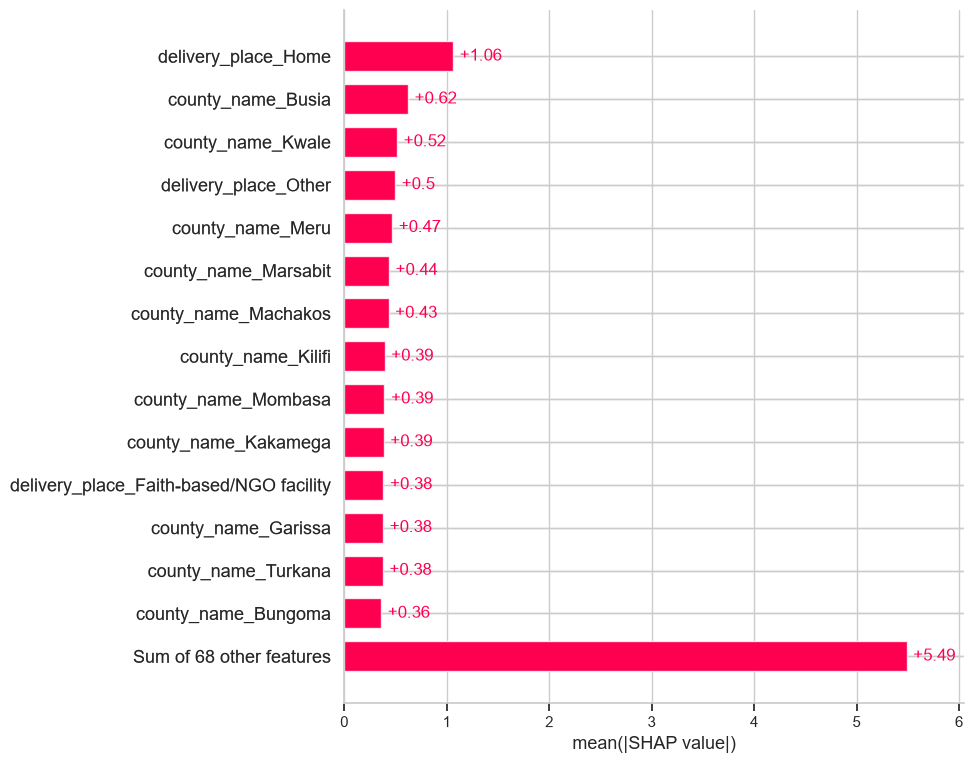

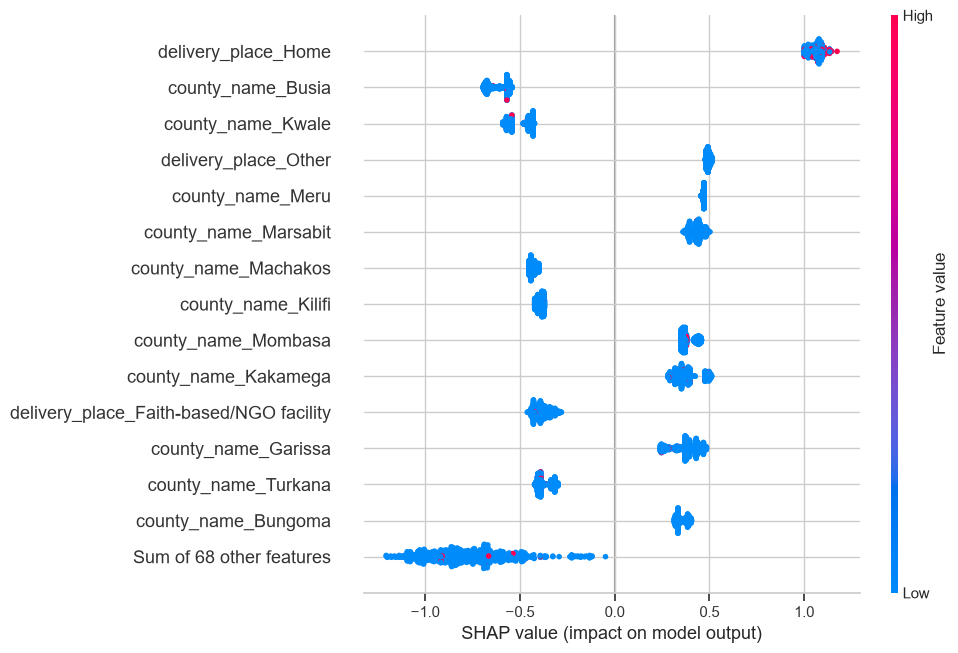

High-risk example — predicted probability: 0.976; actual outcome: 1


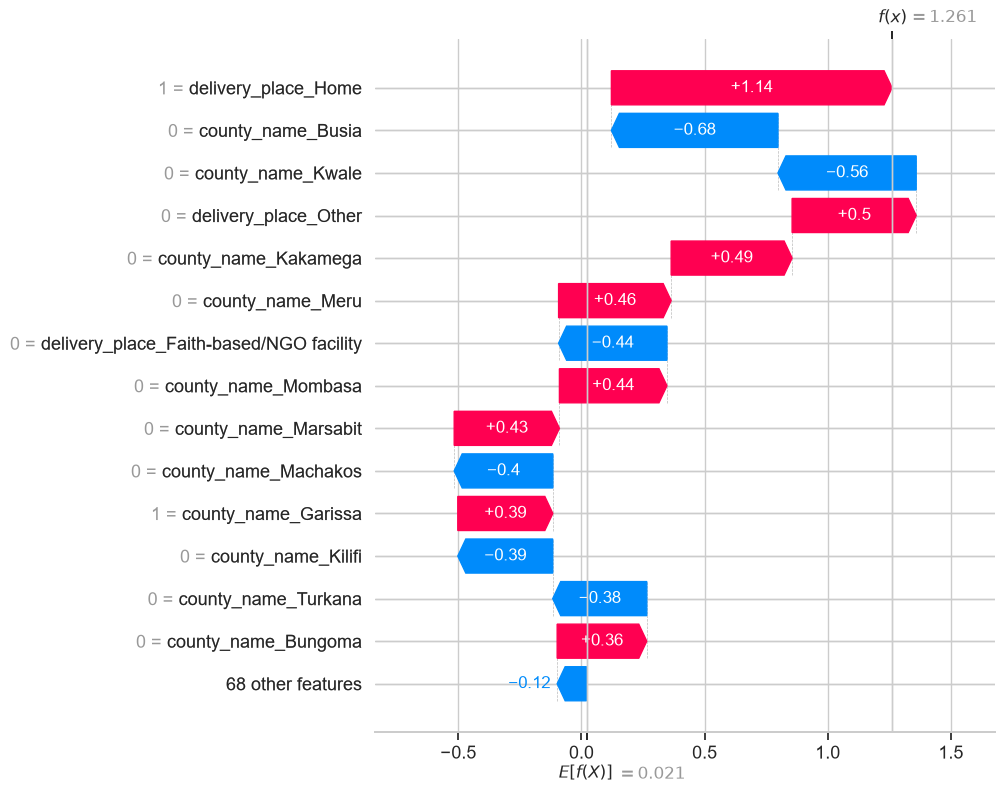

Low-risk example — predicted probability: 0.052; actual outcome: 0


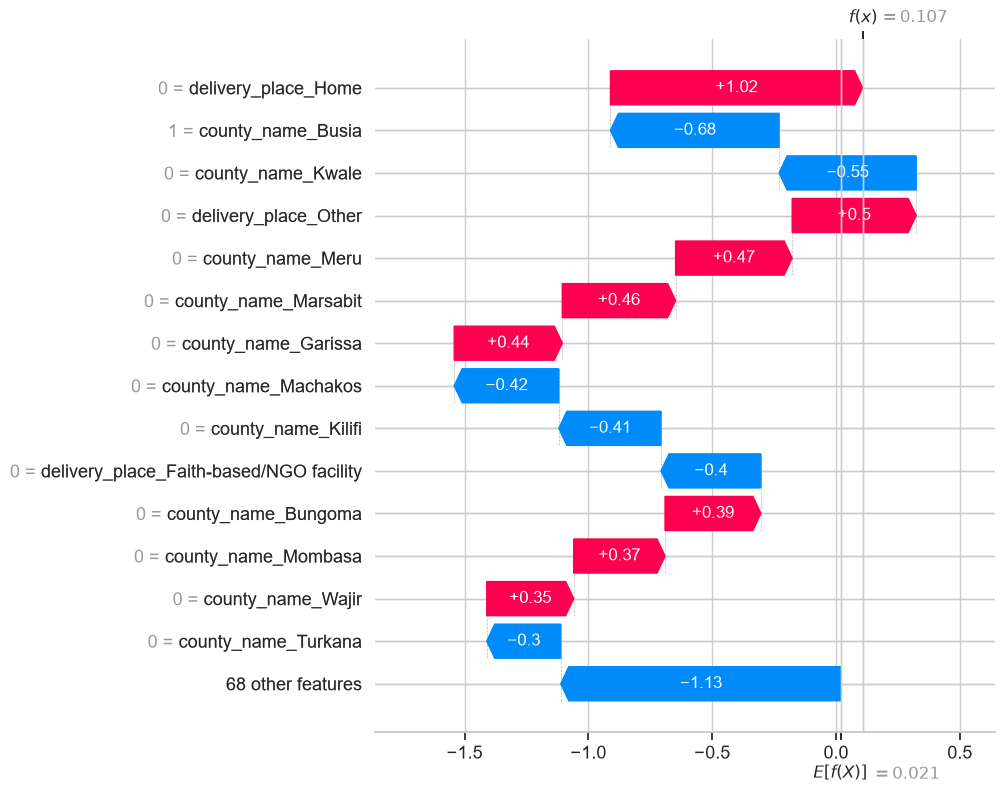

In [61]:
import shap

shap_pipeline = tuned_xgboost
if selected_model_name != "Tuned XGBoost":
    print(f"Selected model: {selected_model_name}")
    print("SHAP is shown for the tuned XGBoost candidate; permutation importance explains the selected model.")

shap_preprocessor = shap_pipeline.named_steps["preprocessing"]
shap_classifier = shap_pipeline.named_steps["model"]
shap_sample = X_test.sample(n=min(1_000, len(X_test)), random_state=42)
shap_transformed = shap_preprocessor.transform(shap_sample)
if hasattr(shap_transformed, "toarray"):
    shap_transformed = shap_transformed.toarray()

shap_feature_names = shap_preprocessor.get_feature_names_out()
shap_explainer = shap.TreeExplainer(shap_classifier)
shap_values = shap_explainer(shap_transformed)
shap_values.feature_names = shap_feature_names.tolist()

shap.plots.bar(shap_values, max_display=15, show=True)
shap.plots.beeswarm(shap_values, max_display=15, show=True)

shap_probabilities = shap_pipeline.predict_proba(shap_sample)[:, 1]
high_risk_position = int(np.argmax(shap_probabilities))
low_risk_position = int(np.argmin(shap_probabilities))

high_risk_index = shap_sample.index[high_risk_position]
low_risk_index = shap_sample.index[low_risk_position]
print(
    f"High-risk example — predicted probability: {shap_probabilities[high_risk_position]:.3f}; "
    f"actual outcome: {y_test.loc[high_risk_index]}"
)
shap.plots.waterfall(shap_values[high_risk_position], max_display=15, show=True)

print(
    f"Low-risk example — predicted probability: {shap_probabilities[low_risk_position]:.3f}; "
    f"actual outcome: {y_test.loc[low_risk_index]}"
)
shap.plots.waterfall(shap_values[low_risk_position], max_display=15, show=True)

### Interpreting Global and Local Feature Dynamics via SHAP Visualizations

To unpack how our champion model handles risk assignment, we analyze our suite of global and local **SHAP (SHapley Additive exPlanations)** visualizations. These plots bridge the gap between general population behaviors and individualized patient prediction pathways.

---

#### 1. Global Feature Importance (Summary Bar Plot)
The horizontal bar chart (`mean(|SHAP value|)`) ranks features based on their average absolute impact on the model's log-odds output across all sampled individuals:
* **Primary Driver:** **`delivery_place_Home`** is the single most dominant individual predictor in the dataset, carrying an average absolute risk impact of **+1.06**. 
* **Regional Disparities:** Specific geographic locations like **`county_name_Busia` (+0.62)** and **`county_name_Kwale` (+0.52)** serve as major regional anchors in risk determination.
* **Collective Information:** The combined effect of the remaining **68 other features (+5.49)** highlights that while home delivery and a few key counties are highly influential, individual patient risk is ultimately computed from a broad, nuanced matrix of socioeconomic and clinical indicators.

---

#### 2. Global Directional Trends (Beeswarm Plot)
The beeswarm plot adds crucial context to the bar chart by illustrating both the magnitude and the **direction** of feature values (where Red represents a high feature value/presence and Blue represents a low feature value/absence):
* **The Home Delivery Risk Vector:** For **`delivery_place_Home`**, the red dots cluster tightly on the far-right side of the axis (SHAP value $> 1.0$). This reveals a definitive structural pattern: giving birth at home heavily drives up the risk of a mother missing her timely postnatal care.
* **Geographic Stratification:** 
  * Living in **Busia** or **Kwale** (indicated by the red dots on the far left) exerts a strong protective effect, significantly pulling a patient's risk profile downward.
  * Conversely, regions like **Kakamega**, **Mombasa**, or **Meru** push risk scores consistently upward, indicating potential localized barriers to accessing timely postnatal care.

---

#### 3. Local Patient Audits (Waterfall Individual Deep-Dives)
The waterfall charts trace the exact mathematical journey of two individual patients, demonstrating how their unique profiles shift them away from the baseline expected population value ($E[f(X)] = 0.021$) to their final log-odds scores ($f(x)$).

* **Case Study A: Low-Risk Pathway ($f(x) = 0.107$)**
  * This patient benefits significantly from living in **Busia (`county_name_Busia = 1`)**, which subtracts **-0.68** from her risk score.
  * She also avoided a home birth (`delivery_place_Home = 0`), which keeps an additional +1.02 penalty off her record.
  * Although generic unlisted attributes (`68 other features = -1.13`) pull her baseline down, a collection of minor positive county-level flags ultimately settles her final prediction score near a low risk threshold.

* **Case Study B: High-Risk Pathway ($f(x) = 1.261$)**
  * This individual possesses the most severe risk configuration in the model: she delivered her child at home (**`delivery_place_Home = 1`**), which instantly penalizes her score by **+1.14**.
  * Additionally, her location in **Kakamega (+0.49)** and **Garissa (+0.39)** compound her vulnerability.
  * Because she lacks protective regional anchors (such as Busia or Kwale, both `0`), her final risk profile surges to an exceptionally high log-odds score of **1.261**, making her a prime candidate for targeted healthcare outreach.

### 6.6 Check performance across key groups

Overall performance can hide unequal results. We therefore report test-set sample size, missed-PNC prevalence, recall, and precision across residence and education groups. Small subgroups should be interpreted cautiously.

In [62]:
def subgroup_metrics(feature):
    rows = []
    feature_values = X_test[feature]
    for group in feature_values.dropna().unique():
        mask = feature_values.eq(group)
        actual = y_test.loc[mask]
        predicted = pd.Series(test_predictions, index=y_test.index).loc[mask]
        rows.append({
            "feature": feature,
            "group": group,
            "test_rows": int(mask.sum()),
            "missed_pnc_percent": 100 * actual.mean(),
            "recall": recall_score(actual, predicted, zero_division=0),
            "precision": precision_score(actual, predicted, zero_division=0),
        })
    return rows

subgroup_table = pd.DataFrame(
    subgroup_metrics("residence") + subgroup_metrics("education_level")
).sort_values(["feature", "group"])

display(subgroup_table.style.format({
    "missed_pnc_percent": "{:.1f}%",
    "recall": "{:.3f}",
    "precision": "{:.3f}",
}))

,feature,group,test_rows,missed_pnc_percent,recall,precision
3,education_level,Higher,318,9.4%,0.600,0.137
5,education_level,No education,436,53.2%,0.991,0.558
4,education_level,Primary,650,23.5%,0.895,0.293
2,education_level,Secondary,688,17.3%,0.790,0.230
1,residence,Rural,1362,31.3%,0.946,0.392
0,residence,Urban,730,14.8%,0.704,0.193


### 6.7 Save the fitted pipeline and evaluation metadata

After the untouched test evaluation, the chosen model is refitted on all development data for later deployment. The saved pipeline includes preprocessing, so new records receive exactly the same transformations. The decision threshold and held-out test metrics are saved separately.

In [63]:
import json
import sys
import sklearn
import xgboost
import shap
import joblib
from sklearn.base import clone

deployment_model = clone(best_model).fit(X_development, y_development)

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "pnc_risk_pipeline.joblib"
METADATA_PATH = MODEL_DIR / "pnc_risk_model_metadata.json"

joblib.dump(deployment_model, MODEL_PATH)

metadata = {
    "target": TARGET,
    "positive_class": "Missed timely PNC",
    "selected_model": selected_model_name,
    "decision_threshold": decision_threshold,
    "predictors": X.columns.tolist(),
    "test_rows": int(len(X_test)),
    "test_metrics": {key: float(value) for key, value in test_metrics.items()},
    "best_parameters": selected_best_parameters,
    "random_state": 42,
    "environment": {
        "conda_environment": "labs-env",
        "python": sys.version.split()[0],
        "scikit_learn": sklearn.__version__,
        "xgboost": xgboost.__version__,
        "shap": shap.__version__,
    },
}
with METADATA_PATH.open("w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)

print(f"Saved model:    {MODEL_PATH.relative_to(PROJECT_ROOT).as_posix()}")
print(f"Saved metadata: {METADATA_PATH.relative_to(PROJECT_ROOT).as_posix()}")

Saved model:    models/pnc_risk_pipeline.joblib
Saved metadata: models/pnc_risk_model_metadata.json


### Evaluation interpretation

- PR-AUC should be compared with the test-set missed-PNC prevalence; meaningful lift above prevalence shows useful ranking ability.
- Recall describes how many women who missed timely PNC were flagged.
- Precision describes how many flagged women actually missed timely PNC.
- The selected F2 threshold deliberately favors recall, but program capacity may require a different threshold.
- Permutation importance shows predictive reliance, not a causal relationship.
- External or temporal validation is still required before clinical or programmatic deployment.

## 7. Deployment

*(Streamlit app — see `/app`.)*

In [64]:
# TODO: link/summary of Streamlit deployment